# Assignment 04 - Optimization, Regularization, and Data Pipelines

### Due: Monday, Feb 16, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References
* Goodfellow, Bengio, Courville (2016). Deep Learning. Ch. 8 (Optimization), Ch. 7 (Regularization)
* Kingma, D. P., & Ba, J. (2014). Adam: A Method for Stochastic Optimization.
* Srivastava, N., et al. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting.
* PyTorch Data Loading and Processing Tutorial: https://pytorch.org/tutorials/beginner/data_loading_tutorial.html
* PyTorch Documentation: https://pytorch.org/docs/stable/index.html
* Weights & Biases Documentation: https://docs.wandb.ai/

In [1]:
from IPython.display import HTML, display

# Define CSS styles in a string variable for reuse across cells
css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

In [2]:
import sys
import os
import time
from enum import Enum

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.0+cu128


In [3]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO: Install Packages</h2></div>
"""))

For students running locally only:

We will be accessing a wide range of data throughout the semester, starting with the **Challenges** in this week's homework. 

1. Open your terminal window
2. Be sure your `csci357` conda environment is active.
3. Execute the following:
```bash
uv pip install ucimlrepo kaggle kagglehub
```

Why install these? — More data!
* `ucimlrepo` — Lets you load UCI Machine Learning Repository datasets directly in Python (e.g. Iris, Adult, Wine). No manual download or path handling; you get more datasets with less setup and can try many datasets quickly for experiments and comparisons.
* `kaggle` — Official Kaggle API client. You can search and download Kaggle datasets and competition data from the command line or from code, so you can use thousands of real-world datasets (tabular, images, text) beyond what’s provided in the homework.
* `kagglehub` — Newer Kaggle dataset loader that works well with the Kaggle ecosystem. It gives you a simple way to download and use Kaggle datasets in Python (e.g. for datasets or pandas), so you have one more reliable way to pull in more data.

In [4]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO: Run Configuration</h2></div>
"""))

# **Notebook Run Configuration**


As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs. 

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run 
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results. 

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [ ]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up our accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [ ]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [ ]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [8]:
# Install any packages that are not part of the standard Google Colab environment
if IN_COLAB:
    !pip install -q wandb
    !pip install -q ucimlrepo kaggle kagglehub
    pass

In [9]:
import wandb

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cb073 (cb073-bucknell-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO: W&B Configuration</h2></div>
"""))

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [ ]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

In [12]:
display(HTML(css_styles + """
<div class="section-box"><h1></h1></div>
"""))

# Background

Last week you built MLPs, used the "magic 5 steps" training loop, and logged experiments
to W&B. You also trained on MNIST using full-batch updates (the whole dataset at once).

This week we level up to the way neural networks are trained in practice: **mini-batches**
and **data pipelines**. You'll also learn how to stabilize and improve training with
**optimizer choices** and **regularization techniques**.

**Key Objectives:**
1. **Data pipeline mastery:** Use `Dataset` and `DataLoader` to create shuffled mini-batches.
2. **Mini-batch training:** Compare stochastic, mini-batch, and full-batch behavior.
3. **`nn.Sequential` deep dive:** Build configurable MLPs fast and clean.
4. **Optimization choices:** Compare SGD, momentum, and Adam in practice.
5. **Regularization:** Apply weight decay, dropout, and early stopping to reduce overfitting.

> As we discussed in class, I'm designing the course intentionally "shifting left" on real-world ML practice, meaning,
> we are covering important activities that are part of the ML workflow, such as data pipelines and experiment tracking. This assignment
> is a key step in preparing you for real-world ML projects. Clean data pipelines and experiment tracking are not optional. They are the foundation
> for reliable training and debugging in modern AI work.

**Let's get started!**

## The Data Pipeline Crisis of 2012

When AlexNet won ImageNet in 2012, the model wasn't the only innovation—the **data pipeline** was.
Training on 1.2 million images required streaming batches from disk while the GPU trained.
Without efficient data loading, training would have taken months instead of weeks.

Last week you trained with **full-batch** updates: loading the entire dataset into memory
and computing gradients on all samples at once. This worked for MNIST (60,000 small images),
but it's completely unrealistic for modern datasets:

- **ImageNet**: 1.2M images, ~150GB
- **LAION-5B**: 5 billion images, ~240TB
- **The Pile** (text): 800GB of text data

The data pipeline becomes the bottleneck long before your model does. Modern training relies on **Mini-batches** -- small batches of samples to keep updates fast, yet noisy enough to **generalize**.

> **Generalization** is the ability of a model to generalize to new data. It's the key to building reliable models. If your model memorizes the training data,
> it will perform poorly on new data. This is the result of an **overfit** model. Generalization is achieved by training on diverse, representative data and using **regularization** techniques.<br><br>
> **Regularization** is a set of techniques used to prevent overfitting by constraining model complexity and encouraging simpler, more generalizable solutions. Common methods include weight decay (L2 penalty on large weights), dropout (randomly deactivating neurons during training), and early stopping (halting training when validation performance stops improving). We're going to discuss these in this week's assignment.

To create mini-batches, we use the PyTorch `DataLoader` and `Dataset` classes, which are powerful utility classes for streaming data efficiently during training. They work together to decouple your data storage from your model training code. They handle batching, shuffling, and parallel data loading on multiple CPU threads, enabling efficient iteration over datasets in manageable chunks.

**Key Insight:** The data pipeline and training loop *are* the engine of deep learning. If you can't build a clean pipeline, you can't train a reliable model. And that's what this week's assignment is all about!


## Dataset vs. DataLoader: The Restaurant Analogy

Here's a fun metaphor to understand how PyTorch data handling works. Think of the PyTorch data ecosystem like a high-end restaurant kitchen:

- **`Dataset` (The Chef)**: The Chef knows *where* the ingredients are and *how* to prepare a single dish. If you ask for dish #42, the Chef goes to the pantry, grabs the ingredients, and prepares that specific meal.
- **`DataLoader` (The Waiter)**: The Waiter doesn't cook. Instead, the Waiter takes a list of orders (indices), organizes them into trays (**batches**), decides the order of service (**shuffling**), and might even hire assistants to bring multiple trays at once (**parallel loading**).

### The Code implementation

To use this in PyTorch, we split the responsibility:

1. **`Dataset`**: A class that defines **what** a single sample looks like.
   - `__len__`: Tells PyTorch how many total samples exist.
   - `__getitem__`: Logic to fetch the $i$-th sample (e.g., loading an image from disk).

2. **`DataLoader`**: A utility that defines **how** we consume the data.

Many of the datasets we'll use to get started will be available as `Dataset` objects. However, for many datasets, it'll be up to you to wrap your data into a PyTorch `Dataset`:

```python
from torch.utils.data import Dataset, DataLoader

# 1. Define the Dataset
class MyDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        # Prepare one sample (e.g. normalize, augment, etc.)
        return self.data[idx]

# 2. Define the DataLoader
loader = DataLoader(
    MyDataset(range(100)),
    batch_size=16,    # Serve 16 dishes at a time
    shuffle=True,     # Randomize order every epoch
    num_workers=2     # Use 2 background threads to "prep" batches
)

# 3. The Training Loop
for batch in loader:
    # 'batch' contains 16 samples ready to be consumed by the model
    train_step(batch)
```

`Dataset` handles the **content**. `DataLoader` handles the **logistics**.



## The Mini-Batch - A batch Size that's "Just Right"

We've seen stochastic training, which updates weights after just one training instance. We've also seen full batch training, where we update weights after the entire dataset has been processed. Neither is ideal in real-world data. Stochastic training usually results in a very erratic loss over each epoch. In contrast, full batch training requires the entire dataset to reside in memory, which is also completely impractical.

In the middle is the **mini-batch**, and you guess it - **batch size** is yet another hyperparameter that often needs to be explored. In training neural nets, choosing a **batch size** follows the same principle.

| Method | Batch Size | Analogy | Pros | Cons |
| :--- | :--- | :--- | :--- | :--- |
| **Stochastic (SGD)** | 1 | **"Too Noisy"** | Escapes sharp minima, low memory | Extremely slow, erratic updates, no vectorization |
| **Full-batch (BGD)** | N (all) | **"Too Rigid"** | Stable gradients, deterministic | Memory intensive, gets stuck in sharp minima, slow per-step |
| **Mini-batch** | 16 - 512 | **"Just Right"** | Fast (GPU parallelization), generalizes well | Requires tuning the batch size |

### Why Mini-batch is the "Just Right" Choice:

1.  **The "Efficiency" Factor (GPU Power)**: GPUs are designed to do many things at once (parallelism). Processing 1 instance of training data at a time is like using a massive cargo ship to deliver a single envelope. A mini-batch fills the "cargo ship" (GPU memory) just enough to be efficient.
2.  **The "Regularization" Factor (Helpful Noise)**: Stochastic updates are messy, but that messiness is actually a feature! Full-batch training often gets stuck in "sharp" local minima that don't generalize. The noise in mini-batches acts like a gentle shaking of the loss landscape, helping the model find "flat" minima that work better on new data.
3.  **The "Memory" Factor**: Modern datasets (like ImageNet) are too large to fit into memory all at once. Mini-batches allow us to train on massive datasets by only looking at a small "bite" at a time.

> **Pro Tip:** When you see a model's performance "plateau," sometimes slightly increasing the batch size or decreasing the learning rate can help it settle into a better solution.



## `nn.Sequential`: The "Assembly Line" of Deep Learning

In PyTorch, `nn.Module` is the base class for all neural network components. Whether it's a single linear layer of Perceptrons, or a complex Transformer, you inherit from this class. `nn.Sequential` is a container that allows you to chain these PyTorch modules together into a single pipeline. It's the most common way to build simple, feed-forward neural networks because it handles the boilerplate of the `forward()` method for you.

### The Analogy: The Assembly Line

Imagine a car **Assembly Line**:
- **Module 1 (Chassis)**: Attaches the frame.
- **Module 2 (Engine)**: Drops in the motor.
- **Module 3 (Wheels)**: Bolts on the tires.

In an assembly line, the output of one station becomes the input of the next. You don't need a manager to manually move the car between every single person; the conveyor belt (the `Sequential` container) does it automatically.

In code, `nn.Sequential` behaves exactly like that conveyor belt:

```python
model = nn.Sequential(
    nn.Linear(784, 128),  # Station 1: Linear projection
    nn.ReLU(),           # Station 2: Non-linear activation
    nn.Dropout(0.2),      # Station 3: Randomly drop neurons (Regularization)
    nn.Linear(128, 10)    # Station 4: Final logits
)
```

### How it Works Under the Hood

When you call `model(x)`, `nn.Sequential` essentially performs a loop:
1. Take `x`, pass it to the first layer.
2. Take the *result*, pass it to the second layer.
3. Repeat until the end and return the final output.

This "auto-forwarding" is why you don't need to define a `forward()` method when using `nn.Sequential` directly.

### Choosing Your Tool

Think of a neural net as a directed graph, where nodes represent `nn.Module` instances, and directed edges represent the data flow from module to module. The number of paths available from the start node pretty much determine if you can use `nn.Sequential` or need to build your own custom `nn.Module` class.

| Use `nn.Sequential` When... | Use a Custom `nn.Module` Class When... |
| :--- | :--- |
| You have a **single path in your layer graph** (input → A → B → C → output) | You need **branching** (e.g., Skip connections in ResNets) |
| You want to **rapidly prototype** or test different depths | You have **multiple inputs or outputs** |
| The model logic is entirely **static** | You need **conditional logic** (e.g., `if training: ...`) |

We'll use this "assembly line" approach to build **configurable MLPs** in just a few lines of code.


## Optimization: The search for the lowest loss

Remember how training a neural network is like trying to find the lowest point in a vast, foggy mountain range (the **Loss Landscape**)? Well, it's not just foggy! The reality is that you're searching while wearing a blindfold! The **optimizer** is the algorithm you use to find that lowest loss.

Let's review a bit about optimizers and introduce a new hyperparameter - **momentum**

### 1. SGD (Stochastic Gradient Descent): The Cautious Hiker

SGD takes a step in the direction that feels steepest downhill.

$$
w_{t+1} = w_t - \eta \nabla L
$$

- **The Learning Rate ($\eta$)**: This is your **step size**. 
    - Too large? You might overshoot the valley and end up on the opposite peak.
    - Too small? It'll take you years to reach the bottom.
- **The Problem**: If the trail is "bumpy" (noisy gradients), SGD gets stuck in every little puddle or takes a zigzag path.

### 2. Momentum: The Heavy Sled

Momentum adds "inertia" to your descent. Imagine sitting on a heavy sled:

$$
v_{t+1} = \beta v_t + (1 - \beta)\nabla L, \quad w_{t+1} = w_t - \eta v_{t+1}
$$

- **The Idea**: Instead of just looking at the current slope, you keep some of your previous speed ($v_t$).
- **The Benefit**: This helps you **smooth out oscillations** (like when the valley is narrow and you keep bouncing off the walls) and **power through small bumps** (local minima) that would stop a regular hiker. 
- **The Friction ($\beta \approx 0.9$):** Controls how much "memory" of past steps you keep.

### 3. Adam: The High-Tech GPS

**Adam (Adaptive Moment Estimation)** is currently the "gold standard" for deep learning. It combines two clever tricks:

1.  **Momentum**: It keeps track of the "average" direction you've been moving (the first moment).
2.  **Adaptive Learning Rates**: It tracks how much the ground is "vibrating" (the variance, or second moment). If a parameter's gradient is changing wildly, Adam slows down; if it's steady, Adam speeds up.

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t, \quad
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
$$

> **Cheat Sheet: Which Optimizer to Pick?**
>
> | Optimizer | Best Used For... | Why? |
> | :--- | :--- | :--- |
> | **Adam** | **Most projects (Default)** | Fast convergence, handles different scales of features automatically, less learning rate (LR) tuning. |
> | **SGD + Momentum** | **SOTA / Fine-tuning** | Often achieves slightly better final accuracy (generalization) if you have time to tune it perfectly. |
> | **Plain SGD** | **Almost Never** | Too slow and prone to getting stuck. Always at least use Momentum. |


## Regularization: Techniques to Prevent Overfitting

Overfitting is the enemy of generalization. This is a challenge of all machine learned models, not just neural nets. If your model is **overfit**, then your model has memorized the training data instead of learning patterns that transfer to new data.

**How to detect overfitting:**
It's actually pretty easy to detect overfitting by observing the following signs:
- Training loss keeps decreasing, but validation loss increases or plateaus
- The "alligator jaws" pattern: train and val curves diverge
- High training accuracy (>99%) but poor test accuracy

Though it's easy to detect overfitting, it's not always easy to fix. Regularization techniques can help, but they're not a silver bullet. They can make your model more robust, but they can also make it less accurate. It's a trade-off, and once again, through optimization techniques and hyperparameter tuning, you can find the right balance to get the best generalization results.

**Three essential regularization tools:**

1. **Weight decay (L2 regularization):** Penalizes large weights to encourage simpler models
   - **What is L2 regularization?** It is a technique where we add a penalty to the loss function equal to the sum of the squares of all the model's weights, multiplied by a factor $\lambda$. This discourages the network from assigning too much importance to any single weight.
   - Mathematically, it adds $\lambda \sum w_i^2$ to the loss, where $w_i$ are the individual weights.
   - In PyTorch: `optimizer = optim.Adam(params, weight_decay=1e-4)` applies this automatically for you.
   - **Intuition:** Large weights make the model more complex and more likely to "memorize" the training data (overfit). By keeping weights small, the model is biased towards simpler solutions that are more likely to generalize well to new data.

2. **Dropout:** Randomly deactivates (drops) a different subset of neurons on each forward pass during training.
   - Each neuron has a probability $p$ of being "dropped" (output set to 0) in every mini-batch.
   - **Yes,** the specific neurons that are dropped are chosen randomly and independently on each training loop (each batch), so the network never knows in advance which neurons will be active.
   - This forces the network to learn redundant, robust features because it cannot rely on any single neuron always being present.
   - Intuition: If your solution can't depend on any one teammate (neuron) always being there, everyone needs to learn to cover for each other!
   - In PyTorch: Use the `torch.nn.Dropout` module. Insert `nn.Dropout(p)` layers in your model to apply dropout with probability $p$.
   - **IMPORTANT!**: Dropout is only active during training (`model.train()`). During evaluation or testing (`model.eval()`), dropout is disabled and all neurons are used.

3. **Early stopping:** Stop training when validation loss stops improving
   - Typically implemented in your training loop: after each epoch, you check if the validation loss has improved.
   - If the validation loss hasn't improved for $N$ consecutive epochs (often referred to as the `patience` hyperparameter), you stop training and restore the model to the weights from the epoch with the best validation loss.
   - Some higher-level libraries (like Keras or PyTorch Lightning) provide built-in EarlyStopping callbacks, but in vanilla PyTorch you usually implement it yourself.
   - Intuition: If you keep training even as the model stopped improving performance on test data, you will overfit. Stop!

We will implement all three and compare their effects using W&B.


## Pro tip: Python tags

**Codetags** are standard tags used in comments to add developer information *and* metadata for most IDEs about the code. We have already been using one widely-adopted standard codetag, **`TODO`**:

```
# TODO: Load MNIST training and test datasets
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
```

`TODO` is a standard codetag. I've never used any IDE that did not have some built-in processing of TODO tags. The IDEs aggregate all of your TODO tags in your codebase, making it easier for you to keep track of things that still have yet to be completed in your code as one coherent checklist! They are incredibly useful.

> Though Python itself does not specify a standard set of codetags, the community has adopted them and expect their developers to adhere to them. (In fact, the community tried to push a standardized list of tags as a proposal to the langauge (see: https://peps.python.org/pep-0350/), way back in 2005! But, they were rejected, noting, *"While the community may be interested, there is no desire to make the standard library conform to this standard."*.) 

I would like you to start being more mindful of using codetags in your code. You can count on the **TODO** tag to be used throughout every notebook to identify code that needs to be completed. I will also introduce the **BUG** tag for code where you specifically need to find a prolem with existing code. (This assignment will have your first **BUG** challenge. You are encouraged to use tags, as they are a standard practice used by the developer community and in industry. It gives you, your team, and future developers who work on your code, a better understanding of the state of your code. 

### Standard Python Codetags

| Codetag | Semantics / Usage |
|---------|--------------------|
| `TODO`    | Indicates something that still needs to be done or implemented. |
| `DONE`    | Indicates that your TODO is DONE. It's tested and ready to be committed. |
| `FIXME`   | Marks code that needs to be fixed; it is known to be problematic or incorrect. |
| `BUG`     | Highlights a known bug or issue in the code that requires attention. |
| `FIXED`   | Indicates that your FIXME or BUG tag has been FIXED. Usually include a comment of what went wrong, as it can be useful to prevent in the future. |
| `???`     | Flags uncertainty, confusion, or a question about how some code works or is intended to work. |
| `!!!`     | Marks code that is especially important, dangerous, or deserving of special attention (e.g., critical warnings). |
| `HACK`    | Signifies a non-ideal, quick, or workaround solution that should be revisited later for a proper fix. |
| `NOTE`    | Used to provide important additional information or clarification to future readers. |

### CSCI 357 - Expected practices
**From now on, you will turn every `TODO` tag into `DONE`, and every `FIXME` or `BUG` tag into `FIXED`.**
* All `FIXED` tags will have a comment following it explaining what was fixed.
* All `DONE` tags will leave the comment that was part of the `TODO`

### Example:

Before:
```
# TODO: Load MNIST training and test datasets
mnist_train = ???
mnist_test = ???
```

After:
```
# DONE: Load MNIST training and test datasets
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
```


In [ ]:
display(HTML(css_styles + """
<div class="section-box"><h1></h1></div>
"""))

# Lab


## Section 1: Data Pipelines with `Dataset` and `DataLoader`

In this section we will load MNIST again, but this time **with `DataLoader`s** so we
can train with **mini-batches** (small chunks of the dataset at a time, like 64 images per step)
instead of using the entire dataset in one giant update.

You'll also see the idea of **transforms**, which are *preprocessing steps* applied to each
data sample **as it is loaded**.

### What is a `transform`?

A **transform** is a function (or pipeline of functions) that takes one data sample and returns
a modified version of it. For images, transforms often do things like:

- convert the image into a PyTorch tensor (`ToTensor`)
- normalize the pixel values to a nicer range for learning (`Normalize`)
- later, we'll learn others like random crops or flips - popular transformations for improving learning with images

In PyTorch, `torchvision.transforms.Compose([...])` lets us *chain* multiple transforms together.
So when you pass `transform=...` to `datasets.MNIST(...)`, PyTorch will automatically apply those
steps inside `__getitem__` every time you request an item from the dataset.

**Big picture:**  
* `Dataset` decides *what one example looks like* (image + label, with transforms applied), and  
* `DataLoader` decides *how we iterate* (batching + shuffling + streaming).


### Question Set 1

1. Load MNIST using `torchvision.datasets`.
2. Create `train_loader` and `test_loader` with a batch size of 64.
3. Enable shuffling for the training loader but not the test loader.
4. Print the shape of one batch of images and labels.
5. Visualize a grid of images from one batch.


In [14]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

In [15]:
# ANSWER
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

# DONE: Define transforms (convert to tensor and normalize to [-1, 1])
# HINT: Use the Normalize transform. The Normalize transform works as follows:
# For each pixel value x (already in [0, 1] after ToTensor()), it computes (x - mean) / std.
# Lookup the parameters! mean=0.5 and std=0.5, so this becomes (x - 0.5) / 0.5 = 2x - 1.
# Therefore, this maps x=0 to -1, x=1 to +1, and any value in between from [-1, 1].
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=0.5, std=0.5)
])

# DONE: Load MNIST training and test datasets - this creates our Dataset objects
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


In [ ]:
# DONE: Set batch size to 64, and create DataLoaders. Shuffle the training DataLoader, not the test DataLoader.
batch_size = 64
train_loader = DataLoader(dataset=mnist_train, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(dataset=mnist_test, shuffle=False, batch_size=batch_size)

In [17]:
# Inspect one batch
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # Should be [64, 1, 28, 28]
print(f"Batch labels shape: {labels.shape}")  # Should be [64]
print(f"First 10 labels in batch: {labels[:10].tolist()}")

Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])
First 10 labels in batch: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]


In [18]:
display(HTML(css_styles + """
<div class="note-box"><h3>Note</h3></div>
"""))

**What is an ideal batch size?**
An ideal batch size depends on several factors, such as the available memory of your hardware (CPU/GPU), the total dataset size, and the model architecture. Smaller batch sizes may result in noisier gradient estimates but can generalize better and require less memory. Larger batch sizes provide more accurate gradient estimates and may train faster per epoch, but they typically require more memory and can sometimes lead to poorer generalization. Common batch sizes are powers of 2 (like 32, 64, 128). For MNIST and similar datasets, a batch size of 64 is a balanced and widely used default. Ultimately, the ideal batch size is found experimentally for each task and hardware setup. Remember, it's another hyperparameter that needs to be explored. 

**Why is the batch shape [64, 1, 28, 28]? What's the "1" for?**
- The dimensions are: [batch_size, channels, height, width].
- Here, batch_size=64, channels=1 (MNIST images are grayscale, so only one channel), height=28, and width=28.
- For color images (like CIFAR-10), channels would be 3 (for RGB).

**Should we specify an accelerator device when getting our Dataset?**
No, we do not need to specify a device (like CPU or GPU) when creating a Dataset. 
Datasets simply represent *references* to the data (like file paths or memory objects) and apply any requested transforms when samples are loaded.

**Should we specify an accelerator device when setting up our DataLoader?**
No, you do not need to specify an accelerator device (such as CPU or GPU) when setting up a DataLoader in PyTorch. The DataLoader is responsible for loading and batching data from the Dataset and is not tied to any specific device. Instead, you move your data batches to the appropriate device (e.g., using `.to(device)`) after they are loaded, typically in your training loop. So, be patient! We'll be getting to utilizing that GPU soon!

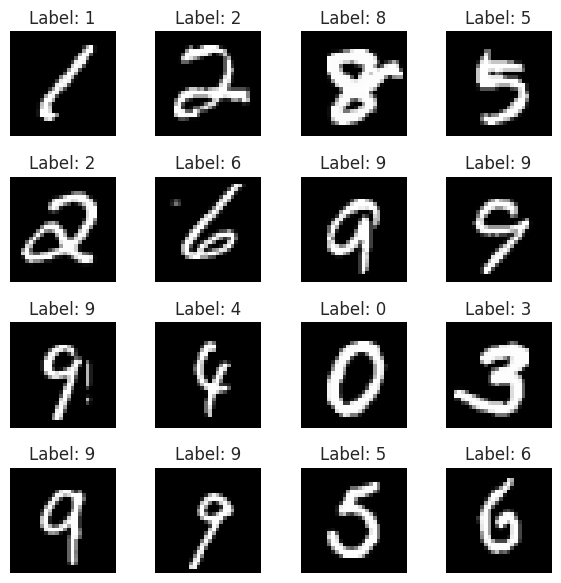

In [19]:
# Visualize a grid of images from the batch
def visualize_batch(images, labels, n_samples=16):
    """
    Displays a grid of images from a batch.

    Args:
        images (torch.Tensor): Tensor containing a batch of images with shape (batch_size, 1, 28, 28).
        labels (torch.Tensor): Tensor containing the corresponding labels with shape (batch_size,).
        n_samples (int): Number of samples to display in the grid.

    Returns:
        None
    """
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))

    # The axes object returned by plt.subplots is a 2D array (since we made a 4x4 grid).
    # flatten() reshapes it into a 1D array so we can easily iterate axes[0], axes[1], ..., axes[15].
    axes = axes.flatten()

    for i in range(min(n_samples, len(images))):
        img = images[i].squeeze().cpu().numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# DONE: Call the above function to visualize a grid of images from the batch
visualize_batch(images=images, labels=labels)

In [ ]:
display(HTML(css_styles + """
<div class="note-box"><h3>Note</h3></div>
"""))

With DataLoaders, each batch is a **mini-dataset**. You now train on a stream of small
batches instead of the full dataset at once. This is the standard approach in deep learning.

**Why `shuffle=True` for training but `shuffle=False` for testing?**
- Training: Shuffling breaks correlations between consecutive samples (e.g., all 0s then all 1s)
- Testing: Order doesn't matter for evaluation, and keeping it consistent aids debugging

**Memory comparison:**
- Full-batch MNIST: Load all 60,000 images into memory (~180MB)
- Mini-batch (64): Load only 64 images at a time (~0.2MB)
- For ImageNet (1.2M images, 150GB), mini-batching is the only feasible approach!
- Mini-batches - **This is the way.**


In [21]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

**Tech Questions - Data Pipelines**

1. How does mini-batch training differ from full-batch in terms of:
   - Memory usage?
   - Convergence speed?
   - Final accuracy?

2. What batch size would you choose for a dataset with 1 million samples? Why?

3. Why is `shuffle=True` important for training but not for testing?


**ANSWER:**

**TODO: FILL IN THE ANSWERS!**

1. Mini-batch training uses less memory as it breaks the data up into smaller batches instead of processing the whole set at once. The convergence speed is faster if we are considering real-time since it can take advantage of GPU parallel processing. Final accuracy generalizes better as it can escape sharp minima, which is indicative of less general models. The noise in the gradients can help improve the generality of the model.



2. I would look at what GPU I have access to, but I think that with 1 million samples, a good range would be 128-512 samples. However, this also depends on the type of work you are trying to achieve with the model. [source](https://ai.stackexchange.com/questions/46568/which-batch-size-is-optimal-for-my-neural-network)



3. It helps avoid the development of correlation between consecutive samples in the training dataset.




---
## Section 2: Building an MLP with `nn.Sequential`

We'll define a helper function to build a configurable MLP using `nn.Sequential`.


In [22]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

### Question Set 2

This is going to give you a chance to use `nn.Dropout`. Let's review:

**How `nn.Dropout(p)` works (briefly):**
- During training (`model.train()`), Dropout randomly sets a fraction `p` of the activations to **0** (independently for each example and each forward pass).
- The remaining activations are **scaled up** by `1/(1-p)` so the expected activation magnitude stays about the same.
- During evaluation (`model.eval()`), Dropout is **turned off** (nothing is zeroed), so predictions are deterministic.

**Where Dropout usually appears, and why:**
- Dropout is typically placed in the **hidden layers**, most commonly **after the nonlinearity introduced by activation functions** (e.g., `Linear → ReLU → Dropout`).
- We usually **do not** apply dropout to the **output (logits) layer**, because, frankly, that'd be silly! Randomly corrupting logits would make learning pretty much impossible.
- Intuition: Dropout discourages “co-adaptation” (neurons relying too much on specific teammates) and nudges the network to learn more robust, redundant features.
- In other words, Dropout is a **regularization** technique: by injecting noise during training, it reduces overfitting and improves **generalization** to unseen data.

---

1. Complete the `create_new_mlp` function below so it constructs the following pattern using `nn.Sequential`:
   - For each hidden layer size `h` in `hidden_units`, add:  
     `nn.Linear(prev_dim, h) → nn.ReLU() → (optional) nn.Dropout(dropout_p)`
   - After the hidden layers, add the output layer:  
     `nn.Linear(last_hidden_dim, output_dim)` (**no activation**; we will use `CrossEntropyLoss`).

2. Use your function to create this exact architecture:
   - `784 → Linear(784, 128) → ReLU → Linear(128, 64) → ReLU → Linear(64, 10)`
   - (If `dropout_p > 0`, insert `Dropout(p=dropout_p)` after each ReLU.)

3. Print the model and count parameters (total and trainable).


In [ ]:
# ANSWER
def create_new_mlp(input_dim: int, hidden_units: list[int], output_dim: int, dropout_p: float = 0.0) -> nn.Sequential:
    """
    Constructs a new MLP using nn.Sequential.

    Args:
        input_dim (int): Number of input features.
        hidden_units (list[int]): Sizes of hidden layers.
        output_dim (int): Number of output classes.
        dropout_p (float): Dropout probability (0 disables dropout).

    Returns:
        nn.Sequential: The MLP model.
    """

    # layers - a list of layers we will use to build the nn.Sequential model
    layers = []
    prev_dim = input_dim

    # DONE: Add Linear + ReLU (+ Dropout if p>0.0) for each hidden layer
    for hidden_dim in hidden_units:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        layers.append(nn.ReLU())
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p)) 
        prev_dim = hidden_dim

    # DONE: Add output layer (no activation - we'll use CrossEntropyLoss which includes softmax)
    layers.append(nn.Linear(prev_dim, output_dim))

    # Why not just pass a list? nn.Sequential expects each module as a separate positional argument
    # (i.e., nn.Sequential(layer1, layer2, ...)), not a single list. The * operator unpacks the
    # list so that each element is passed as its own argument. Otherwise, doing
    # nn.Sequential(layers) would treat the whole list as a single module,
    # which is not what we want! Cool scheisse! 
    return nn.Sequential(*layers)


# DONE: Use your create_new_mlp function to build a 784 -> 128 -> 64 -> 10 model
model = create_new_mlp(input_dim=784, hidden_units=[128, 64], output_dim=10)
print(model)
print()

def count_parameters(model: nn.Module) -> tuple[int, int]:
    """
    Counts total and trainable parameters in a model.

    Args:
        model (nn.Module): PyTorch model.

    Returns:
        tuple[int, int]: (total_params, trainable_params)
    """
    # DONE: Count total and trainable parameters
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 109,386
Trainable parameters: 109,386


In [ ]:
display(HTML(css_styles + """
<div class="note-box"><h2>NOTE</h2></div>
"""))

### Why are total and trainable parameters identical?

That's a good question, and it'd be a challenging tech interview question. Generally, for new models you are training from scratch, all parameters (weights and biases) in your model are trainable, i.e. `requires_grad=True`. However, we're going to learn about **transfer learning** in the coming weeks. 

**Transfer learning** is a technique where a neural network model developed for a task with plenty of data (such as image classification on ImageNet) is reused as the starting point for a new model on a different task. In this setting, you often **freeze** some layers—typically the early feature-extracting layers—so their parameters are not updated during training on the new task. In PyTorch, you do this by setting `requires_grad=False` for those parameters. As a result, only a subset of the model's parameters are trainable, while the rest remain fixed (not updated by backpropagation). That's when the total number of parameters and the number of trainable parameters will differ. Until then, you'll usually see these identical.

In [25]:
display(HTML(css_styles + """
<div class="note-box"><h2>NOTE</h2></div>
"""))

### When would you **NOT** want to use `nn.Sequential`?

`nn.Sequential` is ideal for a **single, straight-through pipeline**:

$x \rightarrow \text{Layer}_1 \rightarrow \text{Layer}_2 \rightarrow \cdots \rightarrow y$

You should **avoid** `nn.Sequential` when your model’s `forward()` is **not just “pass the output to the next layer.”** Common cases:

1. **Skip / residual connections (needs access to earlier tensors)**
   - Example idea: `y = x + F(x)` or concatenations like `y = torch.cat([x, F(x)], dim=...)`

2. **Recurrent networks**
   - When we get to time series models, we'll see that we intentionally need to feed the output back to the input. So, while some of the network can utilize `nn.Sequential`, not all of it can.

2. **Multiple inputs or multiple outputs**
   - Example: `(image, text) → model → (class_logits, bbox_coords)`  
   - Example: encoder–decoder models that return both intermediate states and outputs

3. **Conditional or dynamic control flow**
   - Example: `if x.mean() > 0: ... else: ...`  
   - Example: mixture-of-experts / routing where the path depends on the input

4. **Weight sharing or reusing the same layer in multiple places**
   - Example: the *same* `nn.Linear` applied at two different points in the computation  
   - (In `Sequential`, each layer is typically used exactly once in order.)

5. **Non-trivial ops between layers (not just Modules in a list)**
   - Examples: attention with masking, indexing/slicing, reshaping that depends on data,
     graph/message passing, custom normalization, etc.

**Rule of thumb:** If you can’t write your model as a simple “assembly line,” write a custom `nn.Module` and define `forward()` explicitly.


---
## Section 3: Mini-Batch Training Loop

We will now implement the **mini-batch** training loop using DataLoaders.


In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

### Question Set 3

1. **`accuracy_from_logits` for Multi-class Classification**
   - Implement the `accuracy_from_logits` function that computes the classification accuracy given the model’s raw logits and the true labels. 
   - Recall:
     - `torch.argmax(logits, dim=1)` returns the predicted class indices by finding the maximum logit along dimension 1 (for each sample in the batch).
     - The predicted class indices are then compared to the true labels (which are integer-encoded, not one-hot).
   - **Questions to consider:**
     - Why do we use the integer label targets, rather than one-hot encoded vectors, for comparison?
     - How does the “argmax” operation relate to the predicted class?

2. **Mini-batch Training Loop: `train_epoch_minibatch`**
   - Implement the function that handles training over mini-batches from a DataLoader:
     - `train_epoch_minibatch`: Perform one training epoch, iterating over the DataLoader, running forward and backward passes, updating model parameters, and tracking loss/accuracy.
   - Make sure you:
     - Use `model.train()` before training (activates dropout, enables batch norm update, etc.).
     - Call `optimizer.zero_grad()` before each backward pass—to prevent gradient accumulation from previous batches.
   - **Questions to consider:**
     - What would happen if you forgot to call `optimizer.zero_grad()`?
     - Why do you need to toggle between `.train()` and `.eval()` modes?

3. **Evaluation Loop: `evaluate_minibatch`**
   - Implement the `evaluate_minibatch` function to compute average loss and accuracy over an entire dataset, using mini-batches from a DataLoader.
   - This function should:
     - Set the model to evaluation mode using `model.eval()`.
     - Iterate through all mini-batches in the DataLoader, run only the forward pass (no gradients), and accumulate total loss and accuracy.
     - Use `torch.no_grad()` to ensure evaluation does not compute gradients.
     - Return the average loss and accuracy for the full dataset.
   - **Questions to consider:**
     - Why is it important to use `model.eval()` during evaluation?
     - What does `torch.no_grad()` do, and why is it used here?

4. **Train for Multiple Epochs & Analyze Performance**
   - Train your model for 10 epochs, recording loss and accuracy on both the training and test sets after each epoch.
   - Report/visualize how accuracy changes from epoch to epoch for both sets.
   - Reflect on:
     - How does the accuracy evolve during training?
     - Is your model overfitting or underfitting? Hint: Compare training vs. test accuracy for signs of overfitting (e.g., high train, low test).
     - What strategies could you use to mitigate overfitting if it occurs (e.g., regularization, dropout, early stopping)?

_Reminder: When answering each sub-question, briefly describe your reasoning and process in markdown cells._

In [27]:
def accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
    """
    Computes accuracy from raw logits and integer labels.

    Args:
        logits (torch.Tensor): Logits of shape (batch_size, num_classes).
        labels (torch.Tensor): Integer labels of shape (batch_size,).

    Returns:
        float: Accuracy as a value in [0, 1].
    """
    # DONE: Convert logits -> predicted classes, then compute accuracy
    # torch.argmax(logits, dim=1) finds the index of the maximum value along dimension 1
    # This gives us the predicted class (0-9 for MNIST)
    predictions = torch.argmax(logits, dim=1)
    accuracy = (predictions == labels).float().mean() 
    return accuracy

In [ ]:
display(HTML(css_styles + """
<div class="warning-box"><h1>IMPORTANT!</h1>
<h3><code>train_epoch_minibatch</code> and <code>evaluate_minibatch</code> are going to be used a lot through the rest of the assignment! Take great care 
to get them right!</h3>
</div>
"""))

In [ ]:
def train_epoch_minibatch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: optim.Optimizer, device: torch.device) -> tuple[float, float]:
    """
    Trains model for one epoch using mini-batches from a DataLoader

    Args:
        model (nn.Module): Model to train.
        loader (DataLoader): DataLoader providing training batches.
        criterion (nn.Module): Loss function.
        optimizer (optim.Optimizer): Optimizer for parameter updates.
        device (torch.device): Device for computation.

    Returns:
        tuple[float, float]: Average loss and accuracy for the epoch.
    """
    # DONE: Set model to training mode (enables dropout, batch norm updates, etc.)
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0

    for X_batch, y_batch in loader:
        # DONE: Flatten images from (batch, 1, 28, 28) to (batch, 784) and move to device
        X_batch = X_batch.view((X_batch.size(0), -1)).to(device)
        y_batch = y_batch.to(device)

        # DONE: Magic 5 steps (zero_grad, forward, loss, backward, step)
        # STEP 1: Clear old gradients (if you forget this, gradients accumulate!)
        optimizer.zero_grad()

        # STEP 2: Forward pass
        logits = model(X_batch)

        # STEP 3: Calculate loss
        loss = criterion(logits, y_batch)

        # STEP 4: Backward pass (compute gradients)
        loss.backward()

        # STEP 5: Update weights
        optimizer.step()

        # DONE: Accumulate loss and accuracy (weighted by batch size for correct averaging)
        running_loss += loss.item() * len(X_batch)
        running_acc += accuracy_from_logits(logits, y_batch) * len(X_batch)
        total_samples += len(X_batch)

    # DONE: Return average loss and accuracy
    avg_loss = running_loss / total_samples
    avg_acc = running_acc / total_samples

    return float(avg_loss), float(avg_acc)

In [ ]:
def evaluate_minibatch(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> tuple[float, float]:
    """
    Evaluates model on a dataset using mini-batches.

    Args:
        model (nn.Module): Model to evaluate.
        loader (DataLoader): DataLoader providing evaluation batches.
        criterion (nn.Module): Loss function.
        device (torch.device): Device for computation.

    Returns:
        tuple[float, float]: Average loss and accuracy for the evaluation set.
    """
    # DONE: Set model to evaluation mode (disables dropout, batch norm uses running stats)
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0

    # DONE: Disable gradient computation (saves memory and speeds up evaluation)
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.view((X_batch.size(0), -1)).to(device)
            y_batch = y_batch.to(device)

            # DONE: Forward pass (no backward pass needed for evaluation)
            logits = model(X_batch)

            # DONE: Compute loss
            loss = criterion(logits, y_batch)

            # DONE: Compute accuracy
            accuracy = accuracy_from_logits(logits, y_batch)

            running_loss += loss.item() * len(X_batch)
            running_acc += accuracy * len(X_batch)
            total_samples += len(X_batch)

    # DONE: Return average loss and accuracy
    avg_loss = running_loss / total_samples
    avg_acc = running_acc / total_samples
    return float(avg_loss), float(avg_acc)

In [33]:
# DONE: We already have our model, so choose device and move model to it
device = accel_device if has_accel else cpu_device
# device = cpu_device
print(f"Training on device: {device}\n")

# Instantiate a new model and move it to the device
model = create_new_mlp(input_dim=784, hidden_units=[128, 64], output_dim=10).to(device)

# DONE: Set batch size to 64, and using your mnist_train and mnist_test datasets, create DataLoaders. Don't forget shuffle=True for training!
batch_size = 256
train_loader = DataLoader(dataset=mnist_train, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(dataset=mnist_test, shuffle=False, batch_size=batch_size)

# DONE: Set up loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

if RUN_TRAINING_MODE != RunTrainingMode.NONE:
    start_time = time.time()

    # DONE: Train for a few epochs. Be sure to specify device
    num_epochs = 10
    if RUN_TRAINING_MODE == RunTrainingMode.QUICK:
        num_epochs = 3
    for epoch in range(num_epochs):
        train_epoch_minibatch(model, train_loader, criterion, optimizer, device)

    print(f"Training complete! Time taken: {time.time() - start_time:.2f} seconds")


Training on device: cuda

Training complete! Time taken: 109.84 seconds


In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

**Questions on training dynamics**

1. With respect to training and test loss and accuracy, what would you look for to see if the model has converged to a good solution? 

**ANSWER:** We would like to see training loss decreasing and plateauing while the test loss is closely tracking it. If training loss is much lower than testing loss, this would indicate overfitting. As for train and test accuracy, we want them to plateau at a high level.





2. EXPERIMENT! Ideally, we'd do something a bit more formally on W&B, but that's coming later. For now, change the epochs to 5, and change the device to `cpu_device` and back. Change the `batch_size` from 64 to 256 or 512. What happened to the training time in each case? Was it what you expected? Explain. 

**ANSWER:** When I changed the epochs to 5, the training time was lower because the model is training through less iterations. When I changed the device to cpu, the training time was much slower as the training cannot take advantage of parallelization that GPUs provide. It seems that increasing batch size leads to shorter training time but with diminishing returns. This is because larger batches mean fewer weight updates per epoch, but each epoch had more computation, so it is not a linearly proportional speedup. The GPU was already being somewhat used with a smaller batch and once it reaches max concurrent parallel processes, the GPU does not provide anymore benefit (GPU memory is full).






## Section 3b: Debugging Exercise - Fix the Broken Model!

One of the most important skills in deep learning is debugging. Models fail in subtle ways,
and you need to develop intuition for what's wrong. Below is a training function that
*should* work but has **three bugs**. Your job: find and fix them!


In [ ]:
display(HTML(css_styles + """
<div class="warning-box"><h3>WARNING: This code is intentionally broken! You must find and fix the bugs.</h3></div>
"""))

### Question Set 3b

1. Run the broken training code below and observe what happens.
2. Identify the three bugs (hint: look at gradients, loss function, and learning rate). 
3. Fix the bugs and explain what was wrong. In the code, I placed a "BUG" around the area there is a bug. REPLACE each with a "FIXED" tag with an explanation of the fix. 
4. Train the corrected model and verify it works (indicated by a dropping loss with each epoch)

In [35]:
# ANSWER - BROKEN VERSION (for students to debug)
def broken_train_epoch(model, loader, criterion, optimizer, device):
    """
    A broken training function. Find the bugs!

    Args:
        model (nn.Module): Model to train.
        loader (DataLoader): DataLoader providing training batches.
        criterion (nn.Module): Loss function.
        optimizer (optim.Optimizer): Optimizer for parameter updates.
        device (torch.device): Device for computation.

    Returns:
        float: Average loss for the epoch.
    """
    model.train()
    running_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.view(X_batch.size(0), -1).to(device)
        y_batch = y_batch.to(device)

        # FIXED 1: Something is missing...
        optimizer.zero_grad()

        logits = model(X_batch)

        # FIXED 2: ???
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / total_samples


# Create a broken model and try to train it
model = create_new_mlp(784, [128, 64], 10).to(device)
criterion = nn.CrossEntropyLoss()

# FIXED 3: ???
optimizer = optim.SGD(model.parameters(), lr=0.01)

print("Training broken model (this will fail!)...")
print("Watch for: exploding loss, NaN values, or no learning\n")

# Try to train for 5 epochs
if RUN_TRAINING_MODE != RunTrainingMode.NONE:
    for epoch in range(5):
        train_loss = broken_train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}")

        # Check for NaN
        if np.isnan(train_loss):
            print("💥 Loss exploded to NaN! Something is very wrong...")
            break

Training broken model (this will fail!)...
Watch for: exploding loss, NaN values, or no learning

Epoch 1: Train Loss = 1.9826
Epoch 2: Train Loss = 1.0146
Epoch 3: Train Loss = 0.5931
Epoch 4: Train Loss = 0.4722
Epoch 5: Train Loss = 0.4159


**ANSWER: The three bugs explained**

**Bug 1:** The optimizer's gradients were not zeroed out in each training epoch, leading to gradient accumulation.

**Bug 2:** Softmax was being applied even though the loss function CrossEntropyLoss already applies it internally for numerical stability.

**Bug 3:** The learning rate of 10.0 was too high.

---
## Section 4: Experimentally comparing optimizer and regularizations 

You must be wondering what the impact actually is of these different regularization and optimization techniques. For now, we're going to focus only on comparing optimizers and their parameters. We will train the same model using different optimizers and compare their learning curves and other data using W&B. We'll also give you the first opportunity to play a bit with weight decay.

### **Weight Decay (`weight_decay`) Guidelines**

#### **Common Values & Typical Ranges**
| Value        | Notation  | Description                       |
|--------------|-----------|-----------------------------------|
| 0.0001       | 1e-4      | Common default                    |
| 0.0005       | 5e-4      | Slightly stronger regularization  |
| 0.001        | 1e-3      | Moderate regularization           |
| 0.01         | 1e-2      | Strong regularization             |
| 0.0          | —         | No weight decay                   |

#### **General Guidelines**
- **Start with `1e-4` (0.0001):**
  - Works well for many tasks
  - Good default for CNNs and MLPs

- **Use lower values (`1e-5` to `1e-4`) if:**
  - Model is underfitting
  - Training loss is high
  - You want less regularization

- **Use higher values (`1e-3` to `1e-2`) if:**
  - Model is overfitting
  - There is a large gap between train and validation accuracy
  - You're working with large models or limited data

- **Use `0.0` if:**
  - You're using other forms of regularization (e.g., dropout, batch norm)
  - The model is already underfitting
  - You're doing transfer learning with frozen layers

In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

### Question Set 4

We need an easy way to create optimizers with different parameters that make it easy to experiment. Follow these instructions:
1. Complete the `make_optimizer` function.
2. Train the model with SGD, SGD+momentum, and Adam for 10 epochs each.
3. Log results to W&B for comparison.


In [37]:
def make_optimizer(params, optimizer_name, lr, momentum=0.9, weight_decay=0.0):
    """
    Factory for optimizers.

    Args:
        params (Iterable[torch.nn.Parameter]): Parameters to optimize.
        optimizer_name (str): One of {"sgd", "momentum", "adam"}.
        lr (float): Learning rate.
        momentum (float): Momentum factor for SGD (if used).
        weight_decay (float): L2 regularization strength.

    Returns:
        torch.optim.Optimizer: Configured optimizer instance.
    """
    if optimizer_name == "sgd":
        # DONE: Return vanilla SGD (no momentum)
        return torch.optim.SGD(params=params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "momentum":
        # DONE: Return SGD with momentum (typically 0.9)
        return torch.optim.SGD(params=params, lr=lr, weight_decay=weight_decay, momentum=momentum)
    elif optimizer_name == "adam":
        # DONE: Return Adam (adaptive learning rates per parameter)
        return torch.optim.Adam(params=params, lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")


def run_optimizer_experiment(optimizer_name, batch_size=64, lr=0.001, momentum=0.9, weight_decay=0.0, epochs=10, device=accel_device) -> tuple[str, dict]:
    """
    Runs a short training experiment with a specified optimizer and logs results to Weights & Biases.

    Args:
        optimizer_name (str): Name of the optimizer to use. Must be one of {"sgd", "momentum", "adam"}.
        batch_size (int, optional): Batch size for training and testing. Defaults to 64.
        lr (float, optional): Learning rate for the optimizer. Defaults to 0.001.
        momentum (float, optional): Momentum factor for SGD optimizer. Applies only if optimizer_name is "momentum". Defaults to 0.9.
        weight_decay (float, optional): L2 regularization strength. Defaults to 0.0.
        epochs (int, optional): Number of epochs to train the model. Defaults to 10.
        device (torch.device, optional): Device to use for model training and evaluation.

    Returns:
        tuple:
            - run_name (str): The name of the W&B run associated with this experiment.
            - history (dict): A dictionary containing the training history with the following keys:
                * "train_loss": List[float], training loss for each epoch.
                * "test_loss": List[float], test loss for each epoch.
                * "train_acc": List[float], training accuracy for each epoch.
                * "test_acc": List[float], test accuracy for each epoch.
    """

    # Instantiate the model, criterion and optimizer
    model = create_new_mlp(784, [128, 64], 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model.parameters(), optimizer_name, lr, momentum, weight_decay)

    # DONE: Create DataLoaders
    train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(mnist_test, batch_size=batch_size)

    # Set up wandb
    if optimizer_name == "momentum":
        run_name = f"{user_initials}-sgd-lr{lr}-mom{momentum}-wd{weight_decay}-bs{batch_size}"
    else:
        run_name = f"{user_initials}-{optimizer_name}-lr{lr}-wd{weight_decay}-bs{batch_size}"

    if DO_WANDB_LOGGING:
    # We'll log this to your own account, ignoring entity
        wandb.init(
            # entity=entity,
            project="csci357-hw04-optimizer-comparison",
            name=run_name,
            config={"optimizer": optimizer_name, "lr": lr, "batch_size": batch_size, "weight_decay": weight_decay, "epochs": epochs},
            reinit=True,
            settings=wandb.Settings(x_stats_sampling_interval=2.0)      # Default log interval for system metrics is 15 seconds. We set it to 2 for shorter runs
        )

    # Let's log our history
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    # Train for the specified number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch_minibatch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate_minibatch(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if DO_WANDB_LOGGING:
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "test_loss": test_loss,
                "test_acc": test_acc
            })

    if DO_WANDB_LOGGING:
        wandb.finish()
        
    return run_name, history


In [44]:
# DONE: Run a variety of experiments with appropriate learning rates. Feel free to adjust this code to set up a loop over different parameters.
# Note: SGD needs higher LR than Adam (no adaptive scaling). Momentum needs lower LR than SGD to offset momentum term. And pay attention to the 
# weight decay guidelines given above!

print("Running optimizer comparison experiments...\n")
history_list = []
if RUN_TRAINING_MODE != RunTrainingMode.NONE:
    if RUN_TRAINING_MODE == RunTrainingMode.QUICK:
        num_epochs = 3
    else:
        num_epochs = 15

batch_size = 64
weight_decay = 1e-4
device = accel_device

# SGD: needs higher LR since no adaptive scaling
history = run_optimizer_experiment("sgd", batch_size=batch_size, lr=0.1, epochs=num_epochs, weight_decay=weight_decay, device=device)
history_list.append(history)

# Momentum: lower LR than SGD since momentum accelerates updates
history = run_optimizer_experiment("momentum", batch_size=batch_size, lr=0.01, momentum=0.9, epochs=num_epochs, weight_decay=weight_decay, device=device)
history_list.append(history)

# Adam: much lower LR since it adapts per-parameter
history = run_optimizer_experiment("adam", batch_size=batch_size, lr=0.001, epochs=num_epochs, weight_decay=weight_decay, device=device)
history_list.append(history)


Running optimizer comparison experiments...



epoch,▁▅█
test_acc,▁▄█
test_loss,█▆▁
train_acc,▁▇█
train_loss,█▂▁
epoch,2
test_acc,0.9571
test_loss,0.13297
train_acc,0.96057
train_loss,0.12882


epoch,▁▅█
test_acc,▁▅█
test_loss,█▄▁
train_acc,▁▇█
train_loss,█▂▁
epoch,2
test_acc,0.9628
test_loss,0.12148
train_acc,0.9611
train_loss,0.12496


epoch,▁▅█
test_acc,▁▄█
test_loss,█▅▁
train_acc,▁▇█
train_loss,█▂▁
epoch,2
test_acc,0.9625
test_loss,0.12107
train_acc,0.9561
train_loss,0.14503


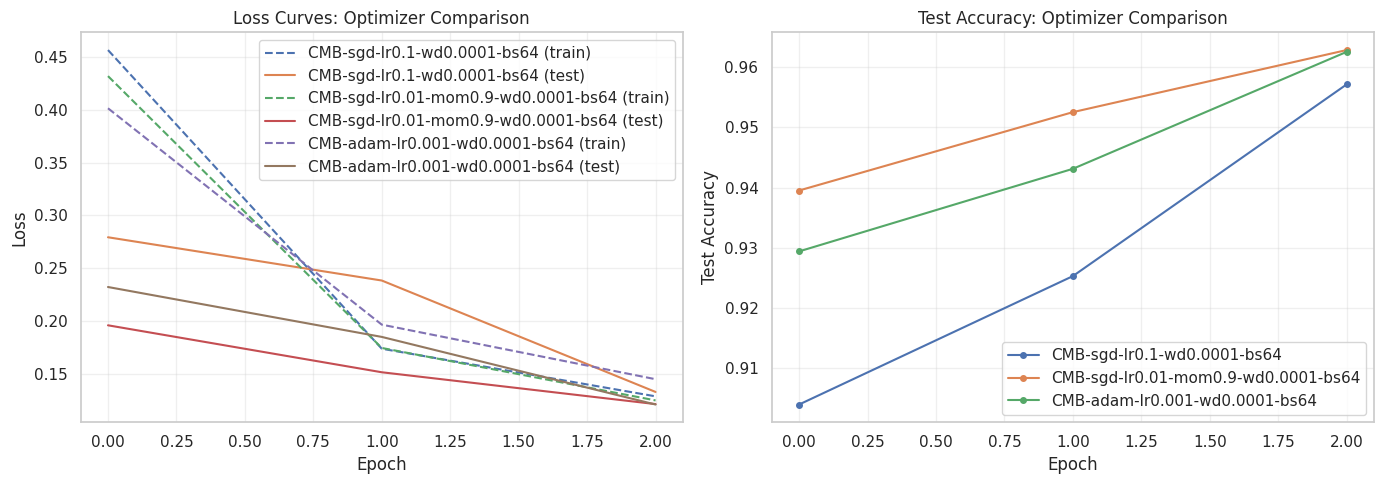

In [45]:
# Visualize optimizer comparison
def plot_optimizer_comparison(histories, labels):
    """
    Plots training curves for multiple optimizers.

    Args:
        histories (list[dict]): List of training histories.
        labels (list[str]): Labels for each optimizer.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot loss curves
    for history, label in zip(histories, labels):
        axes[0].plot(history["train_loss"], label=f"{label} (train)", linestyle='--')
        axes[0].plot(history["test_loss"], label=f"{label} (test)", linestyle='-')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves: Optimizer Comparison")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot accuracy curves
    for history, label in zip(histories, labels):
        axes[1].plot(history["test_acc"], label=label, marker='o', markersize=4)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Test Accuracy")
    axes[1].set_title("Test Accuracy: Optimizer Comparison")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if RUN_TRAINING_MODE != RunTrainingMode.NONE:
    names = [history[0] for history in history_list]
    history_list = [history[1] for history in history_list]
    plot_optimizer_comparison(
        history_list,
        names
    )


**Reflection Questions:**
1. Why does Adam converge faster? When might you prefer SGD+momentum?
2. Adam does not have a momentum parameter, but has `beta1` and `beta2`. Explain what these are, their default values. Are they typically used in practice?

**ANSWER:**


**When to prefer SGD+Momentum:**
Adam converges faster because each parameter has learning rates adapt based on its gradient history. SGD+momentum is better for creating a more general model as Adam can lead to more specific models where they converge to sharper minima. 



**Adam does not use a 'momentum' parameter directly. Instead, it uses 'betas':**

beta1 has a default value of 0.9 and beta2 has a default value of 0.999. beta1 controls the exponential moving average of momentum (first moment). beta2 controls the exponential moving average of the second moment that dictates the per-parameter learning rates. It tracks how large each parameter's gradients have been recently, and scales the LR down for parameters with large gradients. They are not typically tuned as these default values work well for most cases.




---
## Section 5: Regularization in Practice

We'll compare three techniques: **weight decay**, **dropout**, and **early stopping**.


In [46]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

### Question Set 5

**Early stopping** is a regularization technique used during training to prevent overfitting. It monitors the validation loss at each epoch, and if the validation loss does not improve after a certain number of epochs (`patience`), training is halted early. 
- `patience`: The number of epochs to wait for an improvement in validation loss before stopping.
- `min_delta`: The minimum decrease in validation loss to qualify as an improvement. If the improvement is less than this amount, it does not reset the patience counter.

We're going to create an overly complex model that will do a fantastic job memorizing the entire training dataset, approaching an error of near 100% training accuracy! But, let's see what happens to the test accuracy.

1. Implement an `EarlyStopper` class with attributes (and constructor parameters) patience and min_delta.
2. Train a model with dropout (p=0.2) and weight decay (1e-4).
3. Use early stopping to prevent overfitting.
4. Visualize the "alligator jaws" of overfitting (train vs val loss divergence).
5. Compare train/val loss curves in W&B.


In [31]:
# ANSWER
class EarlyStopper:
    """
    Implements early stopping to halt training when validation loss stops improving.

    Early stopping tracks the validation loss after each epoch. If the loss does not
    decrease by at least `min_delta` after `patience` consecutive epochs, training will stop.
    This helps prevent overfitting by stopping when the model's performance on validation data
    stagnates or worsens.

    Args:
        patience (int): Number of epochs to wait after the last improvement before stopping.
        min_delta (float): Minimum reduction in validation loss to qualify as an improvement.
    """
    def __init__(self, patience=3, min_delta=0.0):
        """Initializes the early stopping tracker."""
        # DONE: Initialize patience counter and best loss tracker
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def step(self, val_loss):
        """
        Updates the early stopping state.

        Args:
            val_loss (float): Current validation loss.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        # DONE: Check if validation loss improved by at least min_delta
        if val_loss >= self.best_loss - self.min_delta:
            self.counter += 1
        else:
            self.best_loss = val_loss
            self.counter = 0

        # DONE: Stop if we've waited for patience epochs without improvement
        if self.counter == self.patience:
            return True
        else:
            return False


In [54]:
device = accel_device
# device = cpu_device

print("Running regularizaton experiment on device:", device)

# DONE: Setup your train_loader and test_loader
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size)

# DONE: Initialize some hyperparameters to evaluate regularization
# Set up initial parameters that will overfit the model. Use a highly complex model with hidden layers like [1024, 1024, 512, 256].
# Disable dropout and weight decay. Use at least 30 epochs.
if RUN_TRAINING_MODE != RunTrainingMode.NONE:
    num_epochs = 30
    if RUN_TRAINING_MODE == RunTrainingMode.QUICK:
        num_epochs = 3

    # DONE: Set up standard model parameters (lr, hidden_layers, dropout_p, weight_decay)
    lr = 0.001
    hidden_layers = [1024, 1024, 512, 256]
    dropout_p = 0.0
    weight_decay = 0.0

    # DONE: Set up early stopping parameters
    es_patience = 3
    es_min_delta = 0.01

    # DONE: Create a regularized model with dropout
    model = create_new_mlp(784, hidden_layers, 10, dropout_p).to(device)

    # DONE: Add weight decay to and Adam optimizer (L2 regularization). Keep learning rate at 0.001
    optimizer = torch.optim.Adam(model.parameters(), weight_decay=weight_decay, lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    # DONE: Initialize early stopping instance with patience of 3 and min_delta of 0.01
    early_stopper = EarlyStopper(es_patience, es_min_delta)

    if DO_WANDB_LOGGING:
        wandb.init(
            # entity=entity,        # Let's keep this on your own account again
            project="csci357-hw04-regularization",
            name=f"{user_initials}-drop{dropout_p}-wd{weight_decay}-pat{es_patience}-del{es_min_delta}",
            config={"batch_size": batch_size,
                "hidden_layers": hidden_layers,
                "lr": lr,
                "dropout": dropout_p, 
                "weight_decay": weight_decay, 
                "patience": es_patience, 
                "min_delta": es_min_delta},
            reinit=True,
            settings=wandb.Settings(x_stats_sampling_interval=5.0)
        )

    # DONE: Train with early stopping
    history_reg = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
    stopped_epoch = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch_minibatch(model, train_loader, criterion, optimizer, device=device)
        test_loss, test_acc = evaluate_minibatch(model, test_loader, criterion, device=device)

        history_reg["train_loss"].append(train_loss)
        history_reg["test_loss"].append(test_loss)
        history_reg["train_acc"].append(train_acc)
        history_reg["test_acc"].append(test_acc)

        train_val_gap = test_loss - train_loss

        if DO_WANDB_LOGGING:
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "test_loss": test_loss,
                "test_acc": test_acc,
                "train_val_gap": train_val_gap
            })

        print(f"Epoch {epoch+1:2d}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}, Gap={train_val_gap:+.4f}")

        # DONE: Check early stopping condition
        if early_stopper.step(test_loss):
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
            print(f"   Best validation loss: {early_stopper.best_loss:.4f}")
            stopped_epoch = epoch
            break

    if DO_WANDB_LOGGING:
        wandb.finish()

Running regularizaton experiment on device: cuda


Epoch  1: Train Loss=0.3218, Test Loss=0.1615, Gap=-0.1603
Epoch  2: Train Loss=0.1570, Test Loss=0.1506, Gap=-0.0064
Epoch  3: Train Loss=0.1223, Test Loss=0.0938, Gap=-0.0285
Epoch  4: Train Loss=0.1010, Test Loss=0.1191, Gap=+0.0182
Epoch  5: Train Loss=0.0841, Test Loss=0.0958, Gap=+0.0117
Epoch  6: Train Loss=0.0736, Test Loss=0.1108, Gap=+0.0372

🛑 Early stopping triggered at epoch 6
   Best validation loss: 0.0938


epoch,▁▂▄▅▇█
test_acc,▁▃█▅▇█
test_loss,█▇▁▄▁▃
train_acc,▁▆▇▇██
train_loss,█▃▂▂▁▁
train_val_gap,▁▆▆▇▇█
epoch,5
test_acc,0.9722
test_loss,0.1108
train_acc,0.9766
train_loss,0.07359


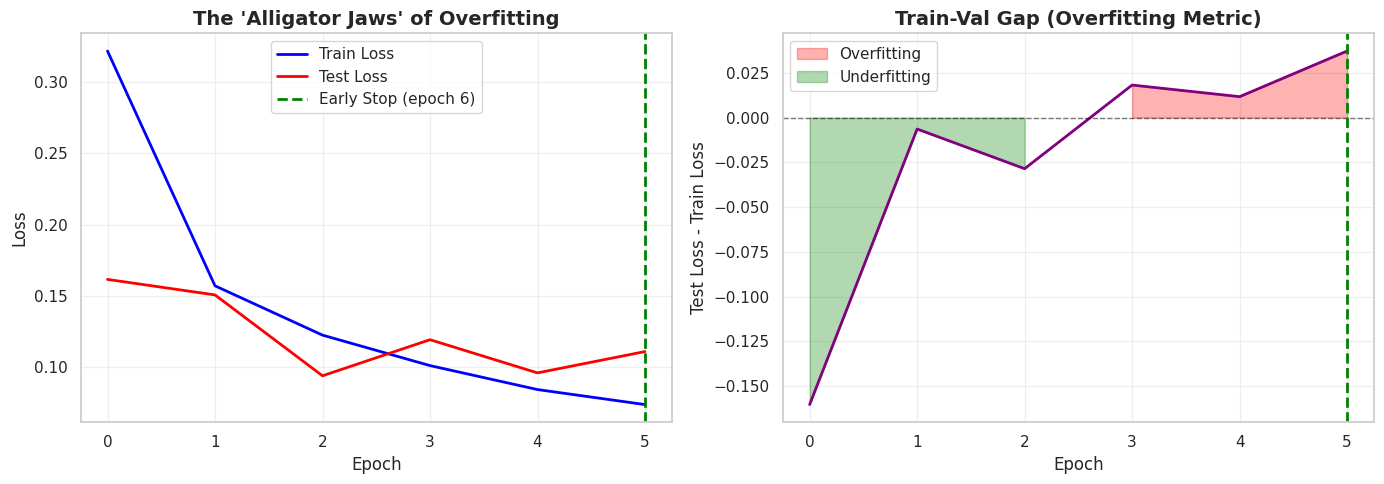

In [55]:
# Visualize the "alligator jaws" of overfitting
def plot_overfitting_analysis(history, stopped_epoch=None):
    """
    Visualizes train vs validation loss to show overfitting.

    Args:
        history (dict): Training history with train_loss and test_loss.
        stopped_epoch (int, optional): Epoch where early stopping triggered.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(len(history["train_loss"]))

    # Plot loss curves
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", linewidth=2, color='blue')
    axes[0].plot(epochs, history["test_loss"], label="Test Loss", linewidth=2, color='red')

    if stopped_epoch is not None:
        axes[0].axvline(stopped_epoch, color='green', linestyle='--', linewidth=2,
                       label=f'Early Stop (epoch {stopped_epoch+1})')

    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("Loss", fontsize=12)
    axes[0].set_title("The 'Alligator Jaws' of Overfitting", fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Plot train-val gap
    gap = [test - train for train, test in zip(history["train_loss"], history["test_loss"])]
    axes[1].plot(epochs, gap, linewidth=2, color='purple')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].fill_between(epochs, 0, gap, where=[g > 0 for g in gap],
                         color='red', alpha=0.3, label='Overfitting')
    axes[1].fill_between(epochs, 0, gap, where=[g < 0 for g in gap],
                         color='green', alpha=0.3, label='Underfitting')

    if stopped_epoch is not None:
        axes[1].axvline(stopped_epoch, color='green', linestyle='--', linewidth=2)

    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_ylabel("Test Loss - Train Loss", fontsize=12)
    axes[1].set_title("Train-Val Gap (Overfitting Metric)", fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_overfitting_analysis(history_reg, stopped_epoch)

**ANSWER: Understanding the visualization**

**Left plot (Alligator Jaws):** The training loss is decreasing while the validation loss starts to increase (diverge).



**Right plot (Train-Val Gap):** We can see that the training loss starts to get smaller than the validation loss, which is a sign of overfitting.




**Key insight:** Regularization (dropout + weight decay) + early stopping work together
to prevent overfitting while maintaining good test performance.

In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

**Questions: Fighting Overfitting**

Think through each question first. Don't just jump to AI. That won't help your understanding.

1. What are the three main signs of overfitting you should watch for?

2. How does dropout work, and why is `model.train()` vs `model.eval()` critical?

3. When would you use weight decay vs dropout vs early stopping? Can you combine them?

4. What's the trade-off between a small model (few parameters) and a large model with heavy regularization?


**ANSWER:**

1. **Three signs of overfitting:** The first sign is when validation loss increases while training loss decreases (diverges). The second sign is if the training and test accuracy are very different (higher training accuracy). The third sign is when test metrics plateaus/worsens while the training metric continues to improve.




2. **Dropout** Dropout works by randomly dropping (setting to 0) activations of neurons. This is done during training, so it is present when the model is in train mode using model.train(). When a model is in eval mode, dropout is disabled, which allows for deterministic evaluations of the dataset.




3. **When to use each:** Weight decay is useful in most models (it is generalizable). Dropouts are useful for larger/complex models with a lot of parameters. Early stoppping is useful in any model, especially when you don't know how many epochs to train with. Yes, you can combine these techniques.





4. **Trade-off:** A small model can be too simple and lead to underfitting. However, a larger model with regularization can learn more complex patterns and regularization prevents overfitting. The only downside is that it is resource-heavy, meaning it will take more compute and time to train.





In [56]:
display(HTML(css_styles + """
<div class="section-box"><h1></h1></div>
"""))

# <div class="section-box">Challenges</div>


 This week, you will tackle five practical challenges designed to deepen your understanding of optimization, regularization, and experimentation in deep learning. Each challenge will prompt you to investigate a different aspect of model training, from hyperparameter sweeps to regularization strategies and interpretability. As you work through these problems, pay close attention to how architectural choices, batch size, and regularization affect your model's ability to learn and generalize. Careful experimentation and thoughtful analysis will help you draw meaningful conclusions from your results. Good luck!

In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

## Challenge 1: Batch Size and Learning Rate Experiment (W&B)

**Objective:** Understand how batch size impacts convergence and generalization.

For this test, you are going to use a much smaller **training** dataset. Why? Because it's important to understand how *slooooow* pure stochastic training is on larger datasets. MNIST is not even really that large. Yet, stochastic training is slow. Why? It's doing an update of all the model weights after every individual instance! Not only does it give noisy losses, but it takes a very, very long time to train! **The smaller the batch size, the longer training time will be!** 

You'll first create a `mnist_train_small` that as random subset of `mnist_train`. Use only 10% of the data.

Write `run_batch_size_experiemnt` whose job is to govern one experiment. The header of the function is given for you. It should govern one complete test with a specified learning rate and batch_size. Those are your two key parameters.

Then, write an experiment loop that iterates over a set FOUR batch sizes (of which 1 and 64 must be 2 of them), and FOUR learning rates: [0.0001, 0.001, 0.01, 0.1] 
* Keep the optimizer (Adam)
* Use the provided wandb.init and log all combinations of runs to W&B (mostly given for you.)
* Compare loss curves and final test accuracy.
* Create a summary table showing batch_size, lr, final_test_acc, and elapsed_time.


In [31]:
# ANSWER
def run_batch_size_experiment(train_data, test_data, batch_size, num_input, hidden_list, num_output, epochs=5, lr=0.001, device=cpu_device):
    """Runs a batch size experiment and logs results to W&B.

    Args:
        train_data: Training dataset.
        test_data: Test dataset.
        batch_size: Batch size to evaluate.
        num_input: Number of input features.
        hidden_list: List of hidden layer sizes.
        num_output: Number of output classes.
        epochs: Number of epochs to train. Defaults to 5.
        lr: Learning rate for Adam optimizer. Defaults to 0.001.
        device: Device to run training on. Defaults to cpu_device.

    Returns:
        Summary dictionary containing batch size results.
    """
    # DONE: Create train and test DataLoaders from the supplied datasetswith specified batch size
    train_loader = DataLoader(train_data, batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size)
    

    # DONE: Build fresh model for each experiment
    model = create_new_mlp(num_input, hidden_list, num_output).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # DONE: Initialize W&B with group for easy comparison
    wandb_experiment = f"bs{batch_size}-lr{lr}"
    wandb_name = f"{user_initials}-{wandb_experiment}"

    if DO_WANDB_LOGGING:
        wandb.init(
        entity=entity,
        project="csci357-hw04-chal01-batchsize",
        group="bs-lr-sweep",
        name=wandb_name,
        config={"batch_size": batch_size, 
                "epochs": epochs,
                "hidden_list": hidden_list,
                "lr": lr},
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=5.0)

        )

    # DONE: Track training time
    start_time = time.time()

    for epoch in range(epochs):
        print(f"Training epoch {epoch+1}...")
        # DONE: Use our previous train_epoch_minibatch function
        train_loss, train_acc = train_epoch_minibatch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate_minibatch(model, test_loader, criterion, device)


        if DO_WANDB_LOGGING:
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "test_loss": test_loss,
                "test_acc": test_acc
            })

    # DONE: Log elapsed time and final metrics
    elapsed_time = time.time() - start_time

    if DO_WANDB_LOGGING:
        wandb.summary["elapsed_time"] = elapsed_time
        wandb.summary["final_test_acc"] = test_acc
        wandb.finish()

    return {
        "batch_size": batch_size,
        "learning_rate": lr,
        "final_test_acc": test_acc,
        "elapsed_time": elapsed_time
    }


In [ ]:
import random
from torch.utils.data import Subset

# DONE: Create a smaller training set from mnist_train of 10% of the data
total = len(mnist_train)
indices = random.sample(range(total), total // 10)
mnist_train_small = Subset(mnist_train, indices)

In [35]:
print("Running batch size / learning rate sweep experiments...\n")
# device = accel_device

# NOTE: I highly recommend using the cpu_device for this challenge. It will take forever to run on the accel_device as you'll spend far more time waiting for data transfers on small batch sizes.
device = cpu_device
num_epochs = 15
if RUN_TRAINING_MODE == RunTrainingMode.NONE:
    num_epochs = 0
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 3

num_input = 784
hidden_list = [64]
num_output = 10
train_data = mnist_train_small
test_data = mnist_test

# DONE: Run experiments with different batch sizes
results = []
batch_sizes = [1, 16, 32, 64]
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]
for batch in batch_sizes:
    for lr in learning_rates:
        result = run_batch_size_experiment(train_data, test_data, batch, num_input, hidden_list, num_output, num_epochs, lr=lr, device=device)
        results.append(result)

# DONE: Create a pandas table of all your results
batch_results_df = pd.DataFrame(results)
print("\n" + "=" * 50)
print("Challenge 01 - Batch Size / Learning Rate Sweep RESULTS")
print("=" * 50)
print(batch_results_df.to_string(index=False))
print()

# DONE: Print top 10 results sorted by final test accuracy
print("Top 10 results sorted by final test accuracy:")
print(batch_results_df.sort_values(by="final_test_acc", ascending=False).head(10))

# DONE: Find best result based on best final test accuracy
best_row = batch_results_df.loc[batch_results_df["final_test_acc"].idxmax()]
best_bs = best_row["batch_size"]
best_lr = best_row["learning_rate"]
best_acc = best_row["final_test_acc"]
print(f"Best batch size: {best_bs} learning rate: {best_lr} (accuracy: {best_acc:.4f})")

Running batch size / learning rate sweep experiments...



epoch,▁█
test_acc,▁█
test_loss,█▁
train_acc,▁█
train_loss,█▁
epoch,1
test_acc,0.8859
test_loss,0.38424
train_acc,0.87017
train_loss,0.44209


Training epoch 1...
Training epoch 2...
Training epoch 3...
Training epoch 4...
Training epoch 5...
Training epoch 6...
Training epoch 7...
Training epoch 8...
Training epoch 9...
Training epoch 10...
Training epoch 11...
Training epoch 12...
Training epoch 13...
Training epoch 14...
Training epoch 15...


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁▁▂▄▅▅▅▇▇▆▆▇▇▇█
test_loss,█▆▅▄▃▃▃▂▂▂▂▂▂▁▁
train_acc,▁▅▅▆▆▆▇▇▇▇▇████
train_loss,█▄▃▃▃▂▂▂▂▂▁▁▁▁▁
elapsed_time,210.67421
epoch,14
final_test_acc,0.9282
test_acc,0.9282
test_loss,0.24271
train_acc,0.95383


Training epoch 1...
Training epoch 2...
Training epoch 3...
Training epoch 4...
Training epoch 5...
Training epoch 6...
Training epoch 7...
Training epoch 8...
Training epoch 9...
Training epoch 10...
Training epoch 11...
Training epoch 12...
Training epoch 13...
Training epoch 14...
Training epoch 15...


...

Training epoch 1...
Training epoch 2...
Training epoch 3...
Training epoch 4...
Training epoch 5...
Training epoch 6...
Training epoch 7...
Training epoch 8...
Training epoch 9...
Training epoch 10...
Training epoch 11...
Training epoch 12...
Training epoch 13...
Training epoch 14...
Training epoch 15...


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁▆▇▁▇▇▆▆██▇█▇▆▇
test_loss,▇▃▂█▁▁▃▃▁▁▂▁▄▄▂
train_acc,▁▆▇▇▇█▇▇█████▇█
train_loss,█▃▂▂▂▂▂▂▁▁▁▁▁▂▁
elapsed_time,45.26535
epoch,14
final_test_acc,0.8931
test_acc,0.8931
test_loss,0.39711
train_acc,0.92167


Training epoch 1...
Training epoch 2...
Training epoch 3...
Training epoch 4...
Training epoch 5...
Training epoch 6...
Training epoch 7...
Training epoch 8...
Training epoch 9...
Training epoch 10...
Training epoch 11...
Training epoch 12...
Training epoch 13...
Training epoch 14...
Training epoch 15...


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,██▄▄▄▄▃▁█▂██▃▄█
test_loss,▁▄█▃▄▄▃▆▇▇▁▄▂▄▃
train_acc,▄█▇█▆▁▇▅▅▁▆▆▅▅▆
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
elapsed_time,45.8443
epoch,14
final_test_acc,0.1135
test_acc,0.1135
test_loss,2.30709
train_acc,0.10633



Challenge 01 - Batch Size / Learning Rate Sweep RESULTS
 batch_size  learning_rate  final_test_acc  elapsed_time
          1         0.0001          0.9282    210.674214
          1         0.0010          0.9045    263.204444
          1         0.0100          0.1009    279.605122
          1         0.1000          0.0980    275.970788
         16         0.0001          0.9097     53.488975
         16         0.0010          0.9212     55.284071
         16         0.0100          0.8784     55.839213
         16         0.1000          0.0980     56.092077
         32         0.0001          0.9061     47.724449
         32         0.0010          0.9277     48.270782
         32         0.0100          0.9020     48.619670
         32         0.1000          0.1135     49.101766
         64         0.0001          0.8989     44.435978
         64         0.0010          0.9240     44.827684
         64         0.0100          0.8931     45.265346
         64         0.1000     

**REFLECTION**

Write a short summary of your findings: 
* which batch size gives the best balance of speed and accuracy? 
* Why does learning rate seem to be dependent on batch size?
* Try to run just one run of batch size = 1 using the GPU. It finishes, but takes far longer than if you just used the cpu. Why? What does this tell you about the ideal batch size?


**ANSWER:** A batch size that was reasonable in speed and accuracy is 16 or 32. Larger batches produce more stable gradients, so the gradient direction is more reliable and can take bigger steps. It takes longer because of IO transfer between the CPU and the GPU. For small batches, the IO dominates the running time while for larger batches, whereas larger batches do not need as many IO transfer, leading to faster running times.






In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

## Challenge 2: Regularization Experiment with Fashion-MNIST

Fashion-MNIST is a dataset of 70,000 grayscale images (28x28 pixels) of clothing items across 10 categories (e.g., t-shirts, trousers, sneakers). It's commonly used as a drop-in replacement for MNIST to benchmark machine learning models on a slightly more challenging image classification task. Best models can typically achieve around 90%, with some reporting that they have been able to achieve up to 94% test accuracy with CNNs, but **you must not use CNNs!** You must restrict yourself to MLPs! (CNNs will be coming in the next week!) 

**Objective:** Identify which regularization and model structure performs the best on Fashion-MNIST

You have no learned about a variety of different techniques to help reduce overfitting and improve generalization

* Weight decay
* Dropout
* Early stopping

For this task, you'll finish a single, comprehensive method, `run_regularization_experiment`. See the header and complete the method. wandb init and logging has been provided for you.

Then, in your next cell, you'll set up your parameters and write nested loops to experiment:
1. Iterate over multiple weight decay, dropout, and early stopping (true or false, don't bother iterating over early stopping parameters)
   - fixed batch size of 256
   - Learning rate of 0.002
   - hidden layer configuration of [512, 128]
2. Log training and test loss and accuracy curves to W&B.
   - Use `wandb_project_name="csci357-hw04-chal02-regularization"` 
   - `wandb_group_name="regularization"`
3. Track the train/validation gap as test_loss - train_loss for each setting. Remember, the more positive, the more the model is overfitting
4. Report which setting reduces the train/val gap most.


In [32]:
# Load in Fashion MNIST data

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fashion_train = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

fashion_test = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]


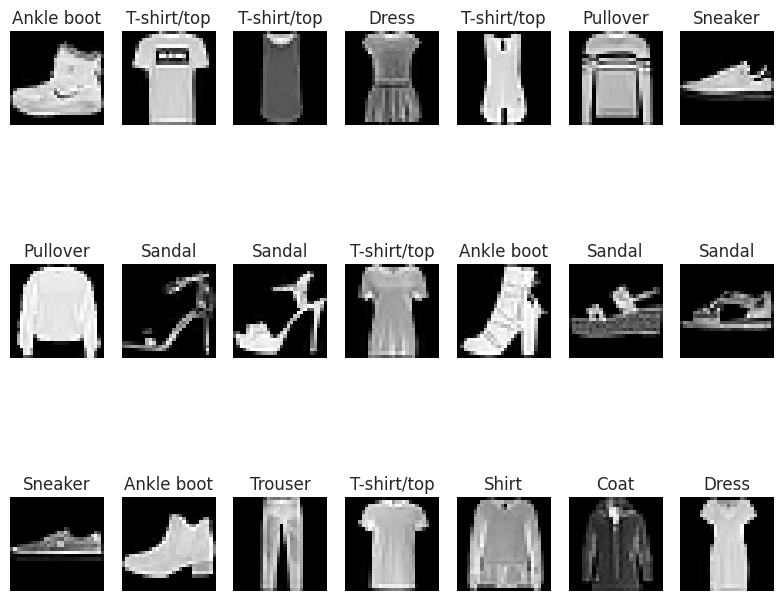

In [33]:
# Let's visualize some of the entries in the dataset, using the actual label names as descriptions in the graph
# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(8, 8))
num_rows = 3
num_cols = 7
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(fashion_train[i][0].squeeze(), cmap='gray')
    plt.title(f"{class_names[fashion_train[i][1]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [33]:
# ANSWER
def run_regularization_experiment(wandb_project_name,wandb_group_name,
                                  train_data, test_data, num_inputs,hidden_list, num_outputs,
                                  batch_size, lr,
                                  dropout_p=0.0, 
                                  weight_decay=0.0,
                                  use_early_stopping=False, 
                                  epochs=20, device=accel_device, criterion_name="CEL", optimizer_name="Adam"):
    """
    Runs a regularization experiment and logs to W&B.

    Args:
        dropout_p (float): Dropout probability.
        weight_decay (float): L2 regularization strength.
        use_early_stopping (bool): Whether to enable early stopping.
        epochs (int): Max epochs to train.

    Returns:
        dict: Final metrics for the setting.
    """

    # DONE: Create train and test DataLoaders with specified batch size
    train_loader = DataLoader(train_data, batch_size, shuffle = True)
    test_loader = DataLoader(test_data, batch_size)

    # DONE: Build model with specified dropout
    model = create_new_mlp(num_inputs, hidden_list, num_outputs, dropout_p).to(device)

    # DONE: Define loss function
    if criterion_name == "CEL":
        criterion = torch.nn.CrossEntropyLoss()
    else:
        raise ValueError(f"Unknown criterion: {criterion_name}")

    # DONE: Add weight decay to Adam optimizer
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
        

    # DONE: Initialize early stopping if requested
    if use_early_stopping:
        early_stopper = EarlyStopper()
        
    total_params, trainable_params = count_parameters(model)

    # Initialize W&B with group
    setting_name = f"hid{hidden_list}-lr{lr}-drop{dropout_p}-wd{weight_decay}-es{use_early_stopping}"

    if DO_WANDB_LOGGING:
        run = wandb.init(
            entity=entity,
            project=wandb_project_name,
            group=f"{user_initials}-{wandb_group_name}",
            name=f"{user_initials}-{setting_name}",
            config={
                "lr": lr,
                "batch_size": batch_size,
                "dropout": dropout_p,
                "weight_decay": weight_decay,
                "early_stopping": use_early_stopping,
                "hidden_list": hidden_list,
                "epochs": epochs,
                "criterion": criterion_name,
                "optimizers": optimizer_name,
                "trainable_params": trainable_params,
            },
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0)
       )

    # DONE: Train and track metrics
    stopped_epoch = None
    start_time = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch_minibatch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate_minibatch(model, test_loader, criterion, device)
        gap = test_loss - train_loss
        if use_early_stopping and early_stopper.step(test_loss):
            stopped_epoch = epoch
            break
        
        if DO_WANDB_LOGGING:
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "test_loss": test_loss,
                "test_acc": test_acc,
                "train_val_gap": gap
            })
        

    train_time = time.time() - start_time
    if DO_WANDB_LOGGING:
        wandb.summary["final_test_acc"] = test_acc
        wandb.summary["final_gap"] = gap
        wandb.summary["stopped_epoch"] = stopped_epoch if stopped_epoch else epochs
        wandb.summary["train_time"] = train_time
        wandb.summary["model_params"] = count_parameters(model)[1]
        wandb.finish()




    return {
        "setting": setting_name,
        "final_test_acc": test_acc,
        "final_gap": gap,
        "train_time": train_time,
        "stopped_epoch": stopped_epoch if stopped_epoch else epochs,
        "trainable_params": trainable_params,
    }

In [35]:
print("Running batch size / learning rate sweep experiments...\n")
device = accel_device
# device = cpu_device
num_epochs = 20
if RUN_TRAINING_MODE == RunTrainingMode.NONE:
    num_epochs = 0
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 3

# Hard code our parameters for this challenge
num_inputs = 784
hidden_list = [512, 256]
num_outputs = 10
batch_size = 256
lr = 0.0025
train_data = fashion_train
test_data = fashion_test

# DONE: Set up our nested loop to run experiments with different regularization parameters. Accumulate the results in the `results` list.
results = [] 
weight_decays = [1e-4, 1e-3, 1e-2]
dropouts = [0.1, 0.2, 0.3]
early_stoppings = [True, False]
for wd in weight_decays:
    for dp in dropouts:
        for es in early_stoppings:
            result = run_regularization_experiment(
                wandb_project_name="csci357-hw04-chal02-regularization",
                wandb_group_name="reg-sweep",
                train_data=train_data, test_data=test_data,
                num_inputs=num_inputs, hidden_list=hidden_list, num_outputs=num_outputs,
                batch_size=batch_size, lr=lr,
                dropout_p=dp, weight_decay=wd,
                use_early_stopping=es, epochs=num_epochs, device=device
            )
            results.append(result)


# DONE: Create a pandas table of all your results
reg_results_df = pd.DataFrame(results)

print("\n" + "=" * 50)
print("Challenge 02 - Regularization Sweep RESULTS")
print("=" * 50)
print(reg_results_df.to_string(index=False))


# DONE: Print top 10 results sorted by final test accuracy
print("\nTop 10 results sorted by final test accuracy:")
print(reg_results_df.sort_values(by="final_test_acc", ascending=False).head(10))



# DONE: Find best result based on best final test accuracy
best_row = reg_results_df.loc[reg_results_df["final_test_acc"].idxmax()]
print(f"\nBest setting: {best_row['setting']} (accuracy: {best_row['final_test_acc']:.4f})")




Running batch size / learning rate sweep experiments...



wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch,▁▂▃▄▅▆▇█
test_acc,▁▄▆▇▆█▇▇
test_loss,█▄▃▂▂▁▂▂
train_acc,▁▅▆▇▇███
train_loss,█▄▃▂▂▂▁▁
train_val_gap,▁▅▆▆▇▆██
epoch,7
final_gap,0.06591
final_test_acc,0.8758
model_params,535818
stopped_epoch,8


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▁▃▄▅▆▅▇▄▆▆▇▇▇█▇▇██▇█
test_loss,█▅▅▄▂▄▂▄▃▃▁▁▂▂▁▁▁▁▂▂
train_acc,▁▄▆▆▆▆▇▇▇▇▇▇▇███████
train_loss,█▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
train_val_gap,▁▅▆▆▆▇▆█▇▇▇▇▇▇▇▇▇███
epoch,19
final_gap,0.09326
final_test_acc,0.8828
model_params,535818
stopped_epoch,20


epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
test_acc,▁▅▃▄▅▆▆▅▆▇▇▇▇▇█▇█▇▇
test_loss,█▅▅▅▄▃▃▄▂▂▂▂▂▂▁▂▁▂▂
train_acc,▁▅▆▆▆▇▇▇▇▇▇████████
train_loss,█▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train_val_gap,▁▄▆▆▇▆▆█▆▆▇▇▇█▆▇▇██
epoch,18
final_gap,0.04757
final_test_acc,0.8811
model_params,535818
stopped_epoch,19


...

epoch,▁▂▄▅▇█
test_acc,▁▃▂█▇▃
test_loss,█▆▅▁▃▅
train_acc,▁▆▇███
train_loss,█▃▂▁▁▁
train_val_gap,▁▆▆▂▅█
epoch,5
final_gap,0.00535
final_test_acc,0.8095
model_params,535818
stopped_epoch,6


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▁▅▅▆█▆▆▃▅▇▇▇▅▇█▇▇▇▇█
test_loss,█▄▃▃▂▅▄▆▄▂▃▃▄▂▁▂▃▂▂▁
train_acc,▁▅▆▇▇▇▇▇▇▇▇▇█▇█████▇
train_loss,█▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁
train_val_gap,▃▃▂▂▁▅▄█▅▂▃▃▆▂▁▂▄▂▂▁
epoch,19
final_gap,-0.03903
final_test_acc,0.8296
model_params,535818
stopped_epoch,20


epoch,▁▂▃▅▆▇█
test_acc,▁▃▄▃█▄▃
test_loss,█▇█▆▁▅▄
train_acc,▁▆▇▇▇██
train_loss,█▃▂▂▂▁▁
train_val_gap,▁▇█▇▄▇▇
epoch,6
final_gap,-0.02719
final_test_acc,0.8131
model_params,535818
stopped_epoch,7


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_acc,▁▅▄▆▄█▆▄▅█▆▇▇█▇▅██▂█
test_loss,█▅▄▃▅▂▃▄▃▂▄▂▂▁▁▂▁▁▆▁
train_acc,▁▆▆▇▇▇▇█▇▇█▇▇███████
train_loss,█▃▃▂▂▂▁▁▂▁▁▁▂▁▁▁▁▁▁▁
train_val_gap,▁▄▄▄▅▂▄▅▄▃▆▃▃▂▂▄▂▃█▃
epoch,19
final_gap,-0.03979
final_test_acc,0.8229
model_params,535818
stopped_epoch,20



Challenge 02 - Regularization Sweep RESULTS
                                        setting  final_test_acc  final_gap  train_time  stopped_epoch
 hid[512, 256]-lr0.0025-drop0.1-wd0.0001-esTrue          0.8758   0.065912  131.207040              8
hid[512, 256]-lr0.0025-drop0.1-wd0.0001-esFalse          0.8828   0.093259  272.577922             20
 hid[512, 256]-lr0.0025-drop0.2-wd0.0001-esTrue          0.8811   0.047575  289.070769             19
hid[512, 256]-lr0.0025-drop0.2-wd0.0001-esFalse          0.8808   0.043585  280.227409             20
 hid[512, 256]-lr0.0025-drop0.3-wd0.0001-esTrue          0.8678   0.015693  126.004749              8
hid[512, 256]-lr0.0025-drop0.3-wd0.0001-esFalse          0.8763   0.022615  277.778660             20
  hid[512, 256]-lr0.0025-drop0.1-wd0.001-esTrue          0.8686   0.018220  180.115165             12
 hid[512, 256]-lr0.0025-drop0.1-wd0.001-esFalse          0.8620   0.053628  278.012464             20
  hid[512, 256]-lr0.0025-drop0.2-wd0.

**ANSWER:**  
In my runs, 0.0025 learning rate, 0.2 dropout, and 0.0001 weight decay produced the smallest train/val gap, indicating the best generalization. Dropout alone helped, but combining techniques was most effective at reducing overfitting. This is the second best result in terms final test accuracy, but had a much lower overfitting validation-test gap than the first one.

In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

## Challenge 3: Custom Dataset + DataLoader

**Objective:** Build your own Dataset class and use DataLoader to train from a dataset in Kaggle or UCIrvine ML Repo

Browse the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php) and [Kaggle](https://www.kaggle.com/datasets) ML dataset repositories. These are two of the most popular sources for machine learning datasets. UCI hosts hundreds of curated datasets across domains like healthcare, finance, and social sciences, while Kaggle offers thousands of community-contributed datasets along with competitions 
and community-supplied notebooks for you to learn from. Both platforms provide excellent opportunities to practice building custom PyTorch datasets and experimenting with 
real-world data beyond standard benchmarks like MNIST or CIFAR-10.

**Tasks:**
1. Find any multiclass dataset from either UCI ML Repo or Kaggle.  
    - You should find something that has a single output that contains multiple classes. That way you have a dataset that is a drop-in replacement for either of the MNISt digits or fashion 
    - Prefer datasets that are relatively balanced (i.e. have near uniform representation among all target classes).  We have NOT covered metrics for imbalanced classification. While **accuracy** is often used in these problems, you would be wrong to do so. Many of the most challenging problems out there are highly imbalanced data. We will discuss these advanced metrics soon.
2. Use the `ucimlrepo` or `kagglehub` to download your data from your cell below.
    - You'll have an easier time finding a dataset of mostly numeric variables. Then, normalize all of the variables (NOT the target!) Otherwise, carefully preprocess the variables to ensure all variables are falling within a similar range (i.e. **normalize your data**! This is **very** important for neural nets!)
3. Randomly split the data into training and testing datasets. Use an 80/20 stratified split.
4. Get your train and test data two into a `Dataset` instance, called `custom_train_dataset`, and `custom_test_dataset` 
5. Set up a loop to try some training cycles with various parameters of your choose. You can use the struture you set up in the previos challenge and make use of `run_regularization_experiemnt`. Pass the the following wandb parameters:
    - `wandb_project_name="csci357-hw04-chal03-custom"`
    - `wandb_group_name="custom_data"`

**EXTRA CHALLENGE**<br>
If the dataset you use is highly unbalanced, then improve `run_regularization_experiment` function to also log a metric called F1 macro average. Accuracy as a performance metric is meaningless for unbalanced data.

In [32]:
# DONE: Load your data from your repository
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split

# 1. Download and load the dataset using ucimlrepo or kagglehub



# 2. Fetch dataset
diabetic_retinopathy_debrecen = fetch_ucirepo(id=329) 


# 3. Set up our X and y data (as pandas dataframes). Be mindful of types! 
X = diabetic_retinopathy_debrecen.data.features 
y = diabetic_retinopathy_debrecen.data.targets 
  
# metadata 
print(diabetic_retinopathy_debrecen.metadata) 
  
# variable information 
print(diabetic_retinopathy_debrecen.variables) 


# 4. Train/test split (e.g. 80/20, stratified on target)
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



{'uci_id': 329, 'name': 'Diabetic Retinopathy Debrecen', 'repository_url': 'https://archive.ics.uci.edu/dataset/329/diabetic+retinopathy+debrecen', 'data_url': 'https://archive.ics.uci.edu/static/public/329/data.csv', 'abstract': 'This dataset contains features extracted from the Messidor image set to predict whether an image contains signs of diabetic retinopathy or not. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1151, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5XP4P', 'creators': ['Balint Antal', 'Andras Hajdu'], 'intro_paper': {'ID': 226, 'type': 'NATIVE', 'title': 'An ensemble-based system for automatic screening of diabetic retinopathy', 'authors': 'B. Antal, A. Hajdu', 'venue': 

**TODO:** Document what these data represent. <br>

**ANSWER:**<br>






In [33]:
# DONE: Show the number of input features, the number of target classes, and the distribution of your target classes

# Set num_inputs and num_outputs
num_inputs = train_X.shape[1]
num_outputs = train_y.nunique().item()

# Show num_inputs and num_outputs
print(f"Number of input features: {num_inputs}")
print(f"Number of target classes: {num_outputs}")

# Show distribution of classes in y
np.unique(y, return_counts=True)

Number of input features: 19
Number of target classes: 2


(array([0, 1]), array([540, 611]))

In [ ]:
# DONE: Normalize your features, then convert your data to PyTorch Dataset instances
#       Name your datasets `custom_train_dataset` and `custom_test_dataset`

from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler

# Standardize X_train and X_test features (recommended for NNs)
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)  # use same mean/std from training set

# Convert to tensors
train_X_tensor = torch.tensor(train_X_scaled, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y.values, dtype=torch.long).squeeze()
test_X_tensor = torch.tensor(test_X_scaled, dtype=torch.float32)
test_y_tensor = torch.tensor(test_y.values, dtype=torch.long).squeeze()

print(train_X_tensor.shape)
print(train_y_tensor.shape)
print(train_y[:5])

# Finally, use TensorDataset to create your custom_train_dataset and custom_test_dataset (same dimension)
custom_train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
custom_test_dataset = TensorDataset(test_X_tensor, test_y_tensor)

torch.Size([920, 19])
torch.Size([920])
      Class
1139      1
880       1
97        0
849       1
723       1


In [42]:
device = accel_device
# device = cpu_device
num_epochs = 20
if RUN_TRAINING_MODE == RunTrainingMode.NONE:
    num_epochs = 0
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 3

# DONE:Hard code parameters we are doing a grid search over for this challenge
# NOTE: num_inputs and num_outputs are already set up in previous cell

batch_size = 64
lr = 0.001
hidden_lists = [[64, 32], [128, 64], [256, 128]]
dropouts = [0.0, 0.1, 0.3]
weight_decays = [0.0, 1e-4, 1e-3]


# DONE: Set up our nested loop to explore parameters. Accumulate the results in the `results` list.
# NOTE: Be sure to use wandb_project_name="csci357-hw04-chal03-custom" and wandb_group_name="custom_data"
results = [] 
for hidden_list in hidden_lists:
    for dp in dropouts:
        for wd in weight_decays:
            result = run_regularization_experiment(
                wandb_project_name="csci357-hw04-chal03-custom",
                wandb_group_name="custom_data",
                train_data=custom_train_dataset, test_data=custom_test_dataset,
                num_inputs=num_inputs, hidden_list=hidden_list, num_outputs=num_outputs,
                batch_size=batch_size, lr=lr,
                dropout_p=dp, weight_decay=wd,
                use_early_stopping=True, epochs=num_epochs, device=device
            )
            results.append(result)



# DONE: Create a pandas table of all your results
custom_results_df = pd.DataFrame(results)

print("\n" + "=" * 50)
print("Challenge 03 - Custom Dataset RESULTS")
print("=" * 50)
print(custom_results_df.to_string(index=False))

# DONE: Print top 10 results sorted by final test accuracy
print("\nTop 10 results sorted by final test accuracy:")
print(custom_results_df.sort_values(by="final_test_acc", ascending=False).head(10))


# DONE: Find best result based on best final test accuracy
best_row = custom_results_df.loc[custom_results_df["final_test_acc"].idxmax()]
print(f"\nBest setting: {best_row['setting']} (accuracy: {best_row['final_test_acc']:.4f})")




wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
test_acc,▂▁▁▃▅█▇▇▅▆▆▅▇▇▆▆▆
test_loss,█▇▆▅▄▃▂▂▂▁▁▁▁▂▁▁▁
train_acc,▁▃▃▃▄▅▆▆▆▇▇▇▇██▇█
train_loss,█▇▆▆▅▅▄▄▃▃▂▂▂▂▁▁▁
train_val_gap,▁▂▂▂▂▂▃▃▄▄▆▆▆▇▇██
epoch,16
final_gap,0.08517
final_test_acc,0.69697
model_params,3426
stopped_epoch,17


epoch,▁▂▂▃▄▄▅▅▆▇▇█
test_acc,▁▁▂▄▇██▆▇█▆▆
test_loss,█▇▆▅▄▃▂▂▂▁▂▁
train_acc,▁▁▂▂▃▅▆▇▇▇██
train_loss,█▇▆▅▅▄▃▃▂▁▁▁
train_val_gap,▁▂▂▂▃▃▄▅▆▆██
epoch,11
final_gap,0.04314
final_test_acc,0.68831
model_params,3426
stopped_epoch,12


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▂▁▂▃▃▄▅▆▇▆█▆▆▇▆
test_loss,█▇▆▅▅▄▄▃▂▂▁▂▁▁▁
train_acc,▁▃▃▃▃▄▅▆▇▇▇▇█▇█
train_loss,█▇▆▆▅▅▄▄▃▃▂▂▂▁▁
train_val_gap,▁▂▂▃▃▃▄▄▄▄▅▇▆██
epoch,14
final_gap,0.05161
final_test_acc,0.69697
model_params,3426
stopped_epoch,15


epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
test_acc,▁▂▃▃▄▄▆▆▇▆▆▇▆▆█▆▇
test_loss,█▇▆▆▅▄▄▃▂▂▂▂▁▁▁▁▁
train_acc,▁▂▄▃▄▄▅▅▆▆▇▇▇██▇█
train_loss,█▇▆▆▆▅▅▄▃▃▃▂▂▂▁▂▁
train_val_gap,▁▂▃▂▂▂▂▂▃▃▄▅▅▇█▇█
epoch,16
final_gap,0.04958
final_test_acc,0.68831
model_params,3426
stopped_epoch,17


...

epoch,▁▂▂▃▄▅▅▆▇▇█
test_acc,▁▆▇▅▇▇▆▆█▇▇
test_loss,█▅▃▂▁▁▁▂▁▁▄
train_acc,▁▄▆▆▆▇█████
train_loss,█▆▅▄▃▂▂▁▁▁▁
train_val_gap,▁▂▂▃▃▄▅▆▅▆█
epoch,10
final_gap,0.06409
final_test_acc,0.70996
model_params,38274
stopped_epoch,11


epoch,▁▂▃▅▆▇█
test_acc,▁▄▆██▇█
test_loss,█▆▄▃▁▁▁
train_acc,▁▄▅▇▇██
train_loss,█▆▄▃▂▂▁
train_val_gap,▁▂▃▂▃▆█
epoch,6
final_gap,0.01661
final_test_acc,0.69697
model_params,38274
stopped_epoch,7


epoch,▁▂▃▄▅▅▆▇█
test_acc,▁▃▄▆█▅▄█▄
test_loss,█▆▄▃▂▁▁▃▂
train_acc,▁▄▅▆▇▇▇██
train_loss,█▆▅▃▃▂▂▂▁
train_val_gap,▁▃▄▄▅▅▅██
epoch,8
final_gap,0.02817
final_test_acc,0.67965
model_params,38274
stopped_epoch,9


epoch,▁▂▂▃▄▄▅▅▆▇▇█
test_acc,▁▅▇▅█▃█▆▆█▆▇
test_loss,█▆▄▂▃▂▂▂▂▁▁▁
train_acc,▁▄▆▇▇▇▇█▇███
train_loss,█▆▅▄▃▃▃▂▂▂▁▁
train_val_gap,▁▄▃▃▅▅▄▇▇▆██
epoch,11
final_gap,0.04165
final_test_acc,0.68831
model_params,38274
stopped_epoch,12



Challenge 03 - Custom Dataset RESULTS
                                      setting  final_test_acc  final_gap  train_time  stopped_epoch
     hid[64, 32]-lr0.001-drop0.0-wd0.0-esTrue        0.696970   0.085167    1.314900             17
  hid[64, 32]-lr0.001-drop0.0-wd0.0001-esTrue        0.688312   0.043144    0.567224             12
   hid[64, 32]-lr0.001-drop0.0-wd0.001-esTrue        0.696970   0.051608    0.628214             15
     hid[64, 32]-lr0.001-drop0.1-wd0.0-esTrue        0.688312   0.049581    0.720459             17
  hid[64, 32]-lr0.001-drop0.1-wd0.0001-esTrue        0.696970   0.044604    0.653432             16
   hid[64, 32]-lr0.001-drop0.1-wd0.001-esTrue        0.705628   0.051047    0.621677             15
     hid[64, 32]-lr0.001-drop0.3-wd0.0-esTrue        0.722944   0.000916    0.818968             20
  hid[64, 32]-lr0.001-drop0.3-wd0.0001-esTrue        0.692641   0.010079    0.772239             19
   hid[64, 32]-lr0.001-drop0.3-wd0.001-esTrue        0.688312

In [ ]:
display(HTML(css_styles + """
<div class="todo-box"><h2>TODO</h2></div>
"""))

## Challenge 4: The Efficiency Frontier (Leaderboard Competition) 🏆

**Objective:** Achieve the highest test accuracy on Fashion MNIST with a strict parameter budget.

**Rules:**
1. Your model must have **<= 500,000 trainable parameters**, and the value must be logged in the summary. Use our previously defined `count_parameters` to report the *trainable* parameter count.
2. You may use any optimizer, regularization, or MLP architecture (MLP only, no CNNs yet!)
3. You must use the same `run_regularization_experiment` function we've been using
    - `wandb_project_name = "csci357-hw04-chal04-leaderboard"`
    - `wandb_group_name= "leaderboard"` 
4. Training budget: **30 epochs maximum**

Your best run must clearly show everything that `run_regularization_experiment` is set to run. 

**Hints**
- Add an additional line that adds teh number of trainable parameters to your wandb summary results. 
    - Use your previously defined `count_parameters` to get the number of trainable parameters.
2. Follow the same code structure for running your experiment that you did with Challenge 2.

3. It's a far more complex dataset. You'll need more neurons in your hidden layers than MNIST digits. 
4. 
**Scoring:**
- Primary metric: Test accuracy (higher is better)
- Tiebreaker: Fewer parameters wins


In [34]:
print("Running batch size / learning rate sweep experiments...\n")
device = accel_device
# device = cpu_device
num_epochs = 30
if RUN_TRAINING_MODE == RunTrainingMode.NONE:
    num_epochs = 0
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 20

num_inputs = 784
num_outputs = 10
train_data = fashion_train
test_data = fashion_test

# DONE: Hard coded parameters here
batch_size = 64
lr = 0.001
hidden_lists = [[64, 64, 64], [256, 64, 10], [256, 256], [512, 128]]
dropouts = [0.1, 0.2]
weight_decays = [1e-4, 1e-3]

# DONE: Set up our nested loop to explore parameters. Accumulate the results in the `batch_results` list.
results = []
for hidden_list in hidden_lists:
    for dp in dropouts:
        for wd in weight_decays:
            result = run_regularization_experiment(
                wandb_project_name="csci357-hw04-chal04-leaderboard",
                wandb_group_name="leaderboard",
                train_data=train_data, test_data=test_data,
                num_inputs=num_inputs, hidden_list=hidden_list, num_outputs=num_outputs,
                batch_size=batch_size, lr=lr,
                dropout_p=dp, weight_decay=wd,
                use_early_stopping=True, epochs=num_epochs, device=device
            )
            results.append(result)

# DONE: Create a pandas table of all your results
leaderboard_df = pd.DataFrame(results)
print("\n" + "=" * 50)
print("Challenge 04 - Leaderboard RESULTS")
print("=" * 50)
print(leaderboard_df.to_string(index=False))


# DONE: Print top 10 results sorted by final test accuracy
print("\nTop 10 results sorted by final test accuracy:")
print(leaderboard_df.sort_values(by="final_test_acc", ascending=False).head(10))


# DONE: Find best result based on best final test accuracy
best_row = leaderboard_df.loc[leaderboard_df["final_test_acc"].idxmax()]
print(f"\nBest setting: {best_row['setting']} (accuracy: {best_row['final_test_acc']:.4f})")


Running batch size / learning rate sweep experiments...



wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch,▁▂▂▃▄▅▅▆▇▇█
test_acc,▁▃▄▅▅▅▆▇███
test_loss,█▆▅▄▅▄▄▂▁▂▂
train_acc,▁▅▆▇▇▇▇████
train_loss,█▄▃▂▂▂▂▁▁▁▁
train_val_gap,▁▆▆▇███▇▇██
epoch,10
final_gap,0.05382
final_test_acc,0.8665
model_params,59210
stopped_epoch,11


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁▂▆▅▅▆██▄▆
test_loss,█▆▃▃▄▃▂▁▄▂
train_acc,▁▆▇▇▇▇████
train_loss,█▃▂▂▂▂▁▁▁▁
train_val_gap,▁▆▆▇▇▇▇▇█▇
epoch,9
final_gap,0.02288
final_test_acc,0.8571
model_params,59210
stopped_epoch,10


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
test_acc,▁▃▄▅▆▆█▇▇▇███
test_loss,█▆▅▄▃▂▂▂▂▂▁▁▂
train_acc,▁▅▆▇▇▇▇▇▇████
train_loss,█▄▃▃▂▂▂▂▁▁▁▁▁
train_val_gap,▁▆▆▇▇▇▇▇▇▇▇██
epoch,12
final_gap,0.024
final_test_acc,0.8696
model_params,59210
stopped_epoch,13


...

epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
test_acc,▁▄▄▄▅▅▇▇█▇█▇▇█▇█
test_loss,█▆▆▅▄▄▃▃▂▂▂▂▂▁▂▁
train_acc,▁▄▅▅▆▆▇▇▇▇▇▇████
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁
train_val_gap,▁▄▆▆▆▇▆▇▆▇▇▇█▇██
epoch,15
final_gap,0.09278
final_test_acc,0.8839
model_params,468874
stopped_epoch,16


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁▆▅▇▇▇▇███
test_loss,█▃▃▂▂▁▂▁▁▂
train_acc,▁▅▆▇▇▇▇███
train_loss,█▄▃▃▂▂▂▁▁▁
train_val_gap,█▁▇▃▅▃▇▄▅▇
epoch,9
final_gap,0.04145
final_test_acc,0.8622
model_params,468874
stopped_epoch,10


epoch,▁▂▂▃▄▅▅▆▇▇█
test_acc,▁▃▅▅▆▆▇▇█▆▇
test_loss,█▅▄▄▃▃▂▂▁▂▁
train_acc,▁▅▆▆▇▇▇████
train_loss,█▄▃▃▂▂▂▁▁▁▁
train_val_gap,▁▅▅▆▆▇▆▇▆█▇
epoch,10
final_gap,0.04483
final_test_acc,0.8804
model_params,468874
stopped_epoch,11


epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
test_acc,▁▃▅▆▆▆▇▆▆▇▇█▆▆▇▇█
test_loss,█▇▅▃▃▃▃▃▃▂▂▁▃▂▁▂▁
train_acc,▁▅▆▆▇▇▇▇▇▇█▇█████
train_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
train_val_gap,▁▆▆▆▆▆▆▇▇▇▆▆█▇▆▇▇
epoch,16
final_gap,0.00863
final_test_acc,0.8679
model_params,468874
stopped_epoch,17



Challenge 04 - Leaderboard RESULTS
                                         setting  final_test_acc  final_gap  train_time  stopped_epoch  trainable_params
 hid[64, 64, 64]-lr0.001-drop0.1-wd0.0001-esTrue          0.8665   0.053825  193.963471             11             59210
  hid[64, 64, 64]-lr0.001-drop0.1-wd0.001-esTrue          0.8571   0.022876  174.545541             10             59210
 hid[64, 64, 64]-lr0.001-drop0.2-wd0.0001-esTrue          0.8696   0.023998  224.336085             13             59210
  hid[64, 64, 64]-lr0.001-drop0.2-wd0.001-esTrue          0.8576  -0.009720  161.650485              9             59210
hid[256, 64, 10]-lr0.001-drop0.1-wd0.0001-esTrue          0.8806   0.035721  273.450086             16            218168
 hid[256, 64, 10]-lr0.001-drop0.1-wd0.001-esTrue          0.8583  -0.008791  158.960195              9            218168
hid[256, 64, 10]-lr0.001-drop0.2-wd0.0001-esTrue          0.8734  -0.038125  309.277452             18            218

**ANSWER: Leaderboard Strategy Writeup**

Summarize your best model. Accuracy? # of parameters? Structure? Hyperparameters?

My best model with an accuracy of 88.39% had the [512, 128] hidden structure layer with a drop value of p=0.1 and gradient decay of 0.0001 and a learning rate of 0.001.





**What I learned:** 

It is difficult to find a good combination of hyperparameters that heavily influence model performance.


In [ ]:
display(HTML(css_styles + """
<div class="section-box"><h1></h1></div>
"""))

# Career Survey

TODO!

[Gartner](https://www.gartner.com/en) is an American research and advisory firm that provides technology- and business-related analysis, forecasts, and recommendations to enterprises, governments, and investors worldwide. On Feb 2, 2026, Gartner released a new study that confirmed a rather striking trend in the workforce - there are an increasing number of companies who are re-hiring humans after laying off due to AI.

Here are a couple of takes on this in the media:

- https://www.digit.fyi/2027-could-be-the-year-of-rehiring-after-ai-drives-job-cuts/
- https://infotechlead.com/artificial-intelligence/gartner-predicts-ai-driven-layoffs-will-reverse-as-companies-rehire-customer-service-staff-by-2027-93381

> Here's a related article from Sept 2, 2025 that discusses how Klarna had to rehire workers because their CEO took costcutting too far:<br>
> - https://www.businessinsider.com/klarna-reassigns-workers-to-customer-support-after-ai-quality-concerns-2025-9

Gartner claims that, "AI simply isn’t mature enough to fully replace the expertise, empathy, and judgment that human agents provide,” said Emily Potosky, Senior Director of Research in the Gartner Customer Service & Support practice. “Relying solely on AI right now is premature and could lead to unintended consequences.”

This is pretty important news right now. They observed an increase in companies who are already planning on reinvesting in human talent to sustain service quality and growth. The rehiring wave, however, won’t simply restore previous roles—workers will likely return under different titles as companies restructure workflows to better integrate human capabilities with AI systems


**TODO:**<br>
First, where do you stand on this? Do you agree or disagree? Why? Then, look to confirm the validity of the Gartner study. Surely there must be other articles that have come out since this Gartner report was released to the public. Find some articles from reputable sources online that have come out over the past couple weeks that confirm these findings in some way. Are there signs that there is a shift in skills toward the human side of computing, HCI, UI, UX, etc. in computing and tech careers? 




**ANSWER:**
<br>
I agree with the core points made in the Gartner study. AI is not a drop-in replacement for human workers, particularly oes that require empathy, judgement, and complex problem-solving. However, the situation is more nuanced than "AI cannot replace humans". We are seeing many companies using AI as an excuse to lay off employees, prematurely optimize AI capabilities, restructuring of positions, and offshoring laid off workforce. An example is this [article](https://hrexecutive.com/the-ai-layoff-trap-why-half-will-be-quietly-rehired/) from HR Executive, detailing how Klarna's employees will have to be rehired. Yes, there are clear signs of renewed emphasis on human-centered skills. For instance, this [article](https://www.index.dev/blog/ui-ux-design-trends) from index.dev also describes how UI/UX is becoming one of the most in-demand, well-compensated roles in tech as products become more user-centered and AI-driven.



In [ ]:
display(HTML(css_styles + """
<div class="section-box"><h1></h1></div>
"""))

# Society

Your reading:

* https://www.cnbc.com/2026/01/27/mozilla-building-an-ai-rebel-alliance-to-take-on-openai-anthropic-.html

January 27, 2026 - CNBC (and many others!) reported that Mozilla is using about $1.4 billion in reserves to back a loose “rebel alliance” of mission-driven AI startups and nonprofits focused on open, transparent, and “trustworthy” AI, positioning itself as a counterweight to dominant players like OpenAI and Anthropic and to Trump administration policies it sees as favoring “winner-take-all” big tech. Yet, Anthropic supposedly claims it has grown revenue rapidly “while deploying AI thoughtfully and responsibly.” 

**Your Prompt:**<br>
Do we even understand how to measure if an AI is "responsible"? How would you operationalize and empirically test “responsible deployment” for large models in the wild? What metrics or experimental designs would you propose?

**ANSWER:**
<br>
I don't think that we have a consensus on measuring whether an AI is "reponsible". There are no unified, validated framework for measuring AI deployment. What exists is competing frameworks, self-reported compliance, post-hoc evaluation, and process metrics over outcome metrics. The existence of Mozilla's rebel alliance is indicative of the lack of clear definitions for "responsible AI", making it quite ironic for the alliance to even exist. I would operationalize and empirically test "responsible deployment" by making sure that these models abide by agreed-upon standards, such as the OpenAPI standard and ensuring it passes specific tests. These tests could include a wide range of different factors, such as ethics, grammar, mathematical accuracy, etc. We would also need some sort of real-world impact monitoring system to ensure that none of these models go "rogue" and start harming society. This could be tested using a longitudinal field study design where we take random samples of users, stratified by demographics and then ask them questions about how AI has affected their day-to-day work. These questions could include job outcomes, accuracy of information received, time spent vs. value received, psychological impacts, etc. Then we could also compare them to a control group that does not have access to AI and conduct statistical analyses.




In [ ]:
display(HTML(css_styles + """
<div class="section-box"><h1></h1></div>
"""))

# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode with Colab

**AI tools used:** Claude

**Short reflection:**
How did you use AI this week? Did it help you understand activation functions? Debug your training loop? Explain backpropagation? Be specific about what worked well and what didn't.

I used AI to debug some of the acceleration code (moving tensors between CPU and GPU).

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)
1. 
```
can you move the tensors back to the CPU:

# Visualize optimizer comparison
def plot_optimizer_comparison(histories, labels):
    """
    Plots training curves for multiple optimizers.

    Args:
        histories (list[dict]): List of training histories.
        labels (list[str]): Labels for each optimizer.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot loss curves
    for history, label in zip(histories, labels):
        axes[0].plot(history["train_loss"], label=f"{label} (train)", linestyle='--')
        axes[0].plot(history["test_loss"], label=f"{label} (test)", linestyle='-')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves: Optimizer Comparison")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot accuracy curves
    for history, label in zip(histories, labels):
        axes[1].plot(history["test_acc"], label=label, marker='o', markersize=4)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Test Accuracy")
    axes[1].set_title("Test Accuracy: Optimizer Comparison")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if RUN_TRAINING_MODE != RunTrainingMode.NONE:
    names = [history[0] for history in history_list]
    history_list = [history[1] for history in history_list]
    plot_optimizer_comparison(
        history_list,
        names
    )
Show less
10:26 PM
The issue is that the values stored in your history dicts might be tensors on GPU. You need to convert them when plotting. Add .cpu() (or .item() if they're scalar tensors) in your run_optimizer_experiment when appending to history:

python
history["train_loss"].append(train_loss if isinstance(train_loss, float) else train_loss.item())
history["test_loss"].append(test_loss if isinstance(test_loss, float) else test_loss.item())
history["train_acc"].append(train_acc if isinstance(train_acc, float) else train_acc.item())
history["test_acc"].append(test_acc if isinstance(test_acc, float) else test_acc.item())
Or more simply, just call .item() on everything since it works on both tensors and is a no-op concept for plain floats — actually .item() only works on tensors. The cleanest fix is to ensure train_epoch_minibatch and evaluate_minibatch return plain Python floats. In those functions, change your return to:

python
return float(avg_loss), float(avg_acc)
float() works on both tensors and Python floats, so it's safe either way and ensures your history always contains CPU Python floats.
```

2. 
```
Help me finish this code. This is the signature of the function:
def run_regularization_experiment(wandb_project_name,wandb_group_name,
                                  train_data, test_data, num_inputs,hidden_list, num_outputs,
                                  batch_size, lr,
                                  dropout_p=0.0, 
                                  weight_decay=0.0,
                                  use_early_stopping=False, 
                                  epochs=20, device=accel_device):

FUNCTION TO COMPLETE:
print("Running batch size / learning rate sweep experiments...\n")
device = accel_device
# device = cpu_device
num_epochs = 20
if RUN_TRAINING_MODE == RunTrainingMode.NONE:
    num_epochs = 0
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 3

# Hard code our parameters for this challenge
num_inputs = 784
hidden_list = [512, 256]
num_outputs = 10
batch_size = 256
lr = 0.0025
train_data = fashion_train
test_data = fashion_test

# DONE: Set up our nested loop to run experiments with different regularization parameters. Accumulate the results in the `results` list.
results = [] 
weight_decays = [1e-4, 1e-3, 1e-2]
dropouts = [0.1, 0.2, 0.3]
early_stoppings = [True, False]
for weight_dec




# DONE: Create a pandas table of all your results



# DONE: Print top 10 results sorted by final test accuracy




# DONE: Find best result based on best final test accuracy
Show less
10:14 AM
python
results = []
weight_decays = [1e-4, 1e-3, 1e-2]
dropouts = [0.1, 0.2, 0.3]
early_stoppings = [True, False]

for wd in weight_decays:
    for dp in dropouts:
        for es in early_stoppings:
            result = run_regularization_experiment(
                wandb_project_name="csci357-hw04-chal02-regularization",
                wandb_group_name="reg-sweep",
                train_data=train_data, test_data=test_data,
                num_inputs=num_inputs, hidden_list=hidden_list, num_outputs=num_outputs,
                batch_size=batch_size, lr=lr,
                dropout_p=dp, weight_decay=wd,
                use_early_stopping=es, epochs=num_epochs, device=device
            )
            results.append(result)

reg_results_df = pd.DataFrame(results)

print("\n" + "=" * 50)
print("Challenge 02 - Regularization Sweep RESULTS")
print("=" * 50)
print(reg_results_df.to_string(index=False))

print("\nTop 10 results sorted by final test accuracy:")
print(reg_results_df.sort_values(by="final_test_acc", ascending=False).head(10))

best_row = reg_results_df.loc[reg_results_df["final_test_acc"].idxmax()]
print(f"\nBest setting: {best_row['setting']} (accuracy: {best_row['final_test_acc']:.4f})")
```

3.
```
# DONE: Normalize your features, then convert your data to PyTorch Dataset instances
#       Name your datasets `custom_train_dataset` and `custom_test_dataset`

from torch.utils.data import TensorDataset

# Standardize X_train and X_test features (recommended for NNs)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=0.5, std=0.5)
])


# Finally, use TensorDataset to create your custom_train_dataset and custom_test_dataset
custom_train_dataset = TensorDataset()
custom_test_dataset = TensorDataset()
Show more
1:02 PM
The transforms.Compose approach is for image data (PIL images). For tabular data, use sklearn's StandardScaler and convert to tensors directly:

python
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)  # use same mean/std from training set

# Convert to tensors
train_X_tensor = torch.tensor(train_X_scaled, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y.values, dtype=torch.long).squeeze()
test_X_tensor = torch.tensor(test_X_scaled, dtype=torch.float32)
test_y_tensor = torch.tensor(test_y.values, dtype=torch.long).squeeze()

# Create datasets
custom_train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
custom_test_dataset = TensorDataset(test_X_tensor, test_y_tensor)
```